# Импорт библиотек

In [993]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных

In [994]:
df_train = pd.read_csv("../data/raw/train.csv") 
df_train.sort_index(inplace=True)
df_train.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


In [995]:
df_test = pd.read_csv("../data/raw/test.csv")
df_test.sort_index(inplace=True)
df_test.head(5)

,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


Удалим ненужный признак Index

In [996]:
test_indices = df_test['index'].copy()

In [997]:
df_train = df_train.drop(columns="index")
df_test = df_test.drop(columns="index")

## Анализ данных

### Первичный осмотр 

In [998]:
df_train.shape  


(751, 213)

In [999]:
df_test.shape

(250, 210)

Обучающий датасет представлен 751 строкой и 214 признаками Тестовый датасет представлен 250 строками, 211 признаками. 3 дополнительных признака в обучающем набором данных обусловлены наличием трех целевых переменных. Соотношение строк train/test составляет примерно 3:1.





In [1000]:
df_train.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

In [1001]:
df_test.dtypes.value_counts()

int64      106
float64    104
Name: count, dtype: int64

Датасеты полностью состоят из числовых данных, что упрощает их использование для большинства моделей машинного обучения без необходимости дополнительного кодирования категориальных переменных. 

### Анализ пропусков 

In [1002]:
df_train.isna().sum().sum()

np.int64(24)

In [1003]:
for col in df_train.columns[df_train.isna().any()]:
    missing_rows = df_train[df_train[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [331, 500]
Колонка 'MinPartialCharge': пропуски в строках [331, 500]
Колонка 'MaxAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'MinAbsPartialCharge': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MWLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_CHGLO': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRHI': пропуски в строках [331, 500]
Колонка 'BCUT2D_MRLOW': пропуски в строках [331, 500]


In [1004]:
df_test.isna().sum().sum()

np.int64(12)

In [1005]:
for col in df_test.columns[df_test.isna().any()]:
    missing_rows = df_test[df_test[col].isna()].index.tolist()
    print(f"Колонка '{col}': пропуски в строках {missing_rows}")

Колонка 'MaxPartialCharge': пропуски в строках [193]
Колонка 'MinPartialCharge': пропуски в строках [193]
Колонка 'MaxAbsPartialCharge': пропуски в строках [193]
Колонка 'MinAbsPartialCharge': пропуски в строках [193]
Колонка 'BCUT2D_MWHI': пропуски в строках [193]
Колонка 'BCUT2D_MWLOW': пропуски в строках [193]
Колонка 'BCUT2D_CHGHI': пропуски в строках [193]
Колонка 'BCUT2D_CHGLO': пропуски в строках [193]
Колонка 'BCUT2D_LOGPHI': пропуски в строках [193]
Колонка 'BCUT2D_LOGPLOW': пропуски в строках [193]
Колонка 'BCUT2D_MRHI': пропуски в строках [193]
Колонка 'BCUT2D_MRLOW': пропуски в строках [193]


In [1006]:
df_train = df_train.drop([331, 500]).reset_index(drop=True)
df_train.shape  


(749, 213)

После анализа пропусков было выявлено, что отсутствующие значения присутствуют только в небольшом числе объектов: строки 331 и 500 в обучающей выборке и строка 193 в тестовой выборке. Пропуски наблюдаются исключительно в дескрипторах, связанных с расчетом электронных характеристик и BCUT-признаков (MaxPartialCharge, MinPartialCharge, BCUT2D_* и др.), что указывает не на случайную потерю данных, а на невозможность корректного вычисления данных дескрипторов для отдельных молекул средствами RDKit.

Поскольку количество проблемных объектов в обучающей выборке крайне мало (2 из 751, менее 0.3%), их удаление является оправданным и позволяет избежать внесения шума в модель. Использование стандартной импутации (mean/median) для подобных физико-химических дескрипторов нежелательно, так как это может привести к появлению химически некорректных значений.

Для тестовой выборки удаление объектов невозможно, поэтому пропуски будут оставлены без изменений. 

### Проверка константных признаков  

In [1007]:
constant_cols_train = [
    c for c in df_train.columns
    if df_train[c].nunique() == 1
]

len(constant_cols_train)

18

In [1008]:
print("Constant columns train:\n")

for i, col in enumerate(constant_cols_train, 1):
    print(f"{i:>2}. {col}")

Constant columns train:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_N_O
 5. fr_SH
 6. fr_azide
 7. fr_barbitur
 8. fr_benzodiazepine
 9. fr_diazo
10. fr_dihydropyridine
11. fr_isocyan
12. fr_isothiocyan
13. fr_lactam
14. fr_nitroso
15. fr_phos_acid
16. fr_phos_ester
17. fr_prisulfonamd
18. fr_thiocyan


In [1009]:
constant_cols_test = [
    c for c in df_test.columns
    if df_test[c].nunique() == 1
]

len(constant_cols_test)

22

In [1010]:
print("Constant columns test:\n")

for i, col in enumerate(constant_cols_test, 1):
    print(f"{i:>2}. {col}")

Constant columns test:

 1. NumRadicalElectrons
 2. SMR_VSA8
 3. SlogP_VSA9
 4. fr_Ar_COO
 5. fr_HOCCN
 6. fr_N_O
 7. fr_SH
 8. fr_azide
 9. fr_barbitur
10. fr_benzodiazepine
11. fr_diazo
12. fr_dihydropyridine
13. fr_isocyan
14. fr_isothiocyan
15. fr_lactam
16. fr_nitroso
17. fr_phos_acid
18. fr_phos_ester
19. fr_prisulfonamd
20. fr_term_acetylene
21. fr_tetrazole
22. fr_thiocyan


В ходе EDA были выявлены константные признаки, принимающие одинаковое значение для всех объектов. Большинство из них относятся к редким функциональным группам (fr_*), отсутствующим в рассматриваемом наборе молекул. Также константными оказались некоторые специализированные дескрипторы (NumRadicalElectrons, SMR_VSA8, SlogP_VSA9).

Поскольку такие признаки не содержат вариативности и не способны разделять объекты, они не несут полезной информации для модели и подлежат удалению.

Удаление выполняется на основе обучающей выборки, после чего одинаковый набор признаков сохраняется как для train, так и для test выборки.

In [1011]:
df_train = df_train.drop(columns=constant_cols_train)

### Проверка на дубликаты строк (полные)

In [1012]:
df_train.duplicated().any()

np.True_

In [1013]:
duplicates = df_train[
    df_train.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 28


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
57,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
66,100.001115,68.000312,0.679996,6.598611,6.598611,0.196181,0.196181,0.607378,57.000000,179.307,...,0,0,0,0,0,0,0,0,0,0
76,11.339368,22.048772,1.944444,5.382755,5.382755,0.119792,0.119792,0.651871,29.500000,317.476,...,0,0,0,0,0,0,0,0,0,0
114,15.728168,43.175363,2.745098,13.604898,13.604898,0.124007,-1.758861,0.390224,11.391304,324.254,...,0,0,0,0,0,0,0,0,0,0
135,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
204,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
220,28.958312,30.695810,1.060000,12.764026,12.764026,0.103258,-4.525895,0.345716,12.130435,345.325,...,0,0,0,0,0,0,0,0,0,0
244,83.619244,2533.916472,30.303030,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,...,0,0,0,0,0,0,0,0,0,0
245,1309.128993,1309.128993,1.000000,12.406138,12.406138,0.004468,-4.546029,0.816512,11.687500,229.157,...,0,0,0,0,0,0,0,0,0,0
260,99.997451,99.997451,1.000000,6.972222,6.972222,0.216042,0.216042,0.779406,46.411765,235.415,...,0,0,0,0,0,0,0,0,0,0


In [1014]:
df_train = df_train.drop_duplicates().reset_index(drop=True)
df_train.duplicated().any()

np.False_

In [1015]:
df_test.duplicated().any()


np.True_

In [1016]:
duplicates = df_test[
    df_test.duplicated(keep=False)
]

print(f"Количество полных дубликатов: {len(duplicates)}")

duplicates

Количество полных дубликатов: 43


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,...,0,0,0,0,0,0,0,0,0,0
2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,...,0,0,0,0,0,0,0,0,0,0
6,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,...,0,0,0,0,0,0,0,0,0,0
8,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,...,0,0,0,0,0,0,0,0,0,0
20,11.118178,11.118178,0.124606,0.124606,0.683345,44.000000,195.306,174.138,195.162314,80,...,0,0,0,0,0,0,0,0,0,0
26,11.223245,11.223245,0.368106,-0.368106,0.688236,10.523810,282.295,268.183,282.089209,106,...,0,0,0,0,0,0,0,0,0,0
37,10.786697,10.786697,0.219687,-1.268911,0.442842,32.882353,244.207,232.111,244.080769,94,...,0,0,0,0,0,0,0,0,0,0
44,10.807343,10.807343,0.053565,-0.593066,0.810440,42.947368,345.302,324.134,344.044563,106,...,0,0,0,0,0,0,0,1,0,0
51,10.807343,10.807343,0.053565,-0.593066,0.810440,42.947368,345.302,324.134,344.044563,106,...,0,0,0,0,0,0,0,1,0,0
53,12.440151,12.440151,0.189653,-4.499733,0.822191,11.687500,245.225,239.177,245.012219,84,...,0,0,0,0,0,0,0,1,0,0


В ходе анализа данных были обнаружены полные дубликаты строк как в обучающей, так и в тестовой выборке. В обучающей выборке найдено 28 полностью совпадающих объектов, а в тестовой — 43.

Для тестовой выборки дубликаты были сохранены, поскольку при формировании итогового submission необходимо получить предсказание для каждого исходного объекта. Удаление строк из test-признаков может привести к несоответствию формата ответа требованиям соревнования. В обучающей выборке они были удалены.

### Выделение групп 

In [1017]:
targets = ["IC50, mM", "CC50, mM", "SI"]

# ГРУППА 1: Общие молекулярные свойства

'''
Описывают базовые физико-химические характеристики молекулы:
массу, размер, липофильность, полярность, площадь поверхности,
лекарствоподобность и общую структурную сложность.
'''

group_general_properties = [
    'qed',
    'SPS',
    'MolWt',
    'HeavyAtomMolWt',
    'ExactMolWt',
    'NumValenceElectrons',
    'MolLogP',
    'MolMR',
    'TPSA',
    'LabuteASA',
    'HeavyAtomCount',
    'FractionCSP3',

    'NHOHCount',
    'NOCount',
    'NumHAcceptors',
    'NumHDonors',
    'NumHeteroatoms',
    'NumRotatableBonds'
]

# ГРУППА 2: Электронные и зарядовые характеристики

'''
Описывают распределение электронной плотности и зарядов в молекуле.
PEOE_VSA дескрипторы характеризуют распределение поверхности
по диапазонам частичных зарядов.
'''

group_electronic_charge = [
    'MaxPartialCharge',
    'MinPartialCharge',
    'MaxAbsPartialCharge',
    'MinAbsPartialCharge',
]

group_peoe_vsa = [
    c for c in df_train.columns
    if c.startswith("PEOE_VSA")
]

# ГРУППА 3: Топологические и структурные дескрипторы

'''
Описывают форму, связность и сложность молекулярного графа.
Chi-дескрипторы характеризуют связность,
Kappa — разветвлённость и цикличность,
BalabanJ и BertzCT — топологическую сложность молекулы.
'''

group_kappa = [
    c for c in df_train.columns
    if c.startswith("Kappa")
]

group_chi = [
    c for c in df_train.columns
    if c.startswith("Chi")
]

group_ring_descriptors = [
    'RingCount',

    'NumAliphaticCarbocycles',
    'NumAliphaticHeterocycles',
    'NumAliphaticRings',

    'NumAromaticCarbocycles',
    'NumAromaticHeterocycles',
    'NumAromaticRings',

    'NumSaturatedCarbocycles',
    'NumSaturatedHeterocycles',
    'NumSaturatedRings',
]

group_topological_structural = [

    'AvgIpc',
    'BalabanJ',
    'BertzCT',
    'HallKierAlpha',
    'Ipc',

    *group_kappa,
    *group_chi,
    *group_ring_descriptors
]

# ГРУППА 4: Поверхностные дескрипторы (VSA)

'''
Описывают распределение ван-дер-ваальсовой поверхности молекулы
по различным физико-химическим свойствам.

• SlogP_VSA  — распределение липофильности
• SMR_VSA    — распределение молярной рефрактивности
• EState_VSA — распределение EState по поверхности
• VSA_EState — распределение поверхности по уровням EState
'''

group_slogp_vsa = [
    c for c in df_train.columns
    if c.startswith("SlogP_VSA")
]

group_smr_vsa = [
    c for c in df_train.columns
    if c.startswith("SMR_VSA")
]

group_estate_vsa = [
    c for c in df_train.columns
    if c.startswith("EState_VSA")
]

group_vsa_estate = [
    c for c in df_train.columns
    if c.startswith("VSA_EState")
]

group_surface_vsa = [
    *group_slogp_vsa,
    *group_smr_vsa,
    *group_estate_vsa,
    *group_vsa_estate
]

# ГРУППА 5: Функциональные группы

'''
Признаки, отражающие количество функциональных групп
и химических фрагментов в молекуле.
Используются для SAR/QSAR анализа.
'''

group_functional_groups = [
    c for c in df_train.columns
    if c.startswith("fr_")
]

# ГРУППА 6: Специфические дескрипторы

'''
Включает специализированные хемоинформатические дескрипторы:

• EState indices —
  электротопологические индексы

• BCUT2D —
  спектральные дескрипторы молекулярного графа

• FpDensityMorgan —
  плотность Morgan fingerprints
'''

group_estate_indices = [
    'MaxAbsEStateIndex',
    'MaxEStateIndex',
    'MinAbsEStateIndex',
    'MinEStateIndex',
]

group_bcut = [
    c for c in df_train.columns
    if c.startswith("BCUT2D")
]

group_morgan_density = [
    c for c in df_train.columns
    if c.startswith("FpDensityMorgan")
]

group_specific_descriptors = [
    *group_estate_indices,
    *group_bcut,
    *group_morgan_density
]

# ИТОГОВЫЙ СЛОВАРЬ ГРУПП


feature_groups = {
    "general_properties": group_general_properties,
    "electronic_charge": group_electronic_charge,
    "peoe_vsa": group_peoe_vsa,
    "topological_structural": group_topological_structural,
    "surface_vsa": group_surface_vsa,
    "functional_groups": group_functional_groups,
    "specific_descriptors": group_specific_descriptors,
}


for group_name, cols in feature_groups.items():
    print(f"{group_name}: {len(cols)}")

general_properties: 18
electronic_charge: 4
peoe_vsa: 14
topological_structural: 30
surface_vsa: 41
functional_groups: 70
specific_descriptors: 15


Все молекулярные дескрипторы были структурированы на 6 основных групп в соответствии с их физико-химическим и хемоинформатическим смыслом. Такой подход позволил систематизировать признаки, упростить анализ мультиколлинеарности и интерпретацию влияния различных молекулярных характеристик на биологическую активность соединений.

В итоговый набор вошли:

- общие физико-химические свойства молекул;
- электронные и зарядовые дескрипторы;
- топологические и структурные характеристики;
- поверхностные VSA-дескрипторы;
- fragment-based признаки функциональных групп;
- специализированные хемоинформатические дескрипторы (EState, BCUT2D, FpDensityMorgan).

Подобное разделение признакового пространства позволило отдельно проанализировать вклад различных классов дескрипторов, выявить избыточные признаки и сохранить наиболее информативные характеристики для дальнейшего нелинейного QSAR-моделирования.

# Feature Engineering  

Feature engineering химических признаков выполняется до удаления мультиколлинеарных групп, поскольку создание новых признаков (например, отношений MolWt к HeavyAtomCount или произведений BertzCT на BalabanJ) может изменить структуру корреляций между переменными. Создание новых признаков может как усилить, так и ослабить существующую мультиколлинеарность, поэтому оценку корреляций и последующее удаление избыточных признаков имеет смысл проводить уже после создания всех потенциально полезных дескрипторов.

In [1018]:
df_train.shape

(734, 195)

In [1019]:
def create_chemistry_features(df):
    X = df.copy()
    
    def safe_div(num, denom):
        return X[num] / (X[denom] + 1e-5)
    
    # Feature 1: Плотность молекулярной массы
    if 'MolWt' in X.columns and 'HeavyAtomCount' in X.columns:
        X['Feature_Density_Wt'] = safe_div('MolWt', 'HeavyAtomCount')
    
    # Feature 2: Липофильность на единицу площади поверхности
    if 'MolLogP' in X.columns and 'LabuteASA' in X.columns:
        X['Feature_LogP_Surface'] = safe_div('MolLogP', 'LabuteASA')
    
    # Feature 3: Доля ароматических колец
    if 'NumAromaticRings' in X.columns and 'RingCount' in X.columns:
        X['Feature_Arom_Ratio'] = safe_div('NumAromaticRings', 'RingCount')
    
    # Feature 4: Количество валентных электронов на один тяжелый атом
    if 'NumValenceElectrons' in X.columns and 'HeavyAtomCount' in X.columns:
        X['Feature_Valence_per_Atom'] = safe_div('NumValenceElectrons', 'HeavyAtomCount')
    
    # Feature 5: Комплексность молекулы (BertzCT * BalabanJ)
    if 'BertzCT' in X.columns and 'BalabanJ' in X.columns:
        X['Feature_Complexity'] = X['BertzCT'] * X['BalabanJ']
    
    return X

df_train = create_chemistry_features(df_train)
df_test = create_chemistry_features(df_test)

df_train.shape

(734, 200)

In [ ]:


group_engineered_features = [
    'Feature_Density_Wt',
    'Feature_LogP_Surface',
    'Feature_Arom_Ratio',
    'Feature_Valence_per_Atom',
    'Feature_Complexity'
]


feature_groups = {
    "general_properties": group_general_properties,
    "electronic_charge": group_electronic_charge,
    "peoe_vsa": group_peoe_vsa,
    "topological_structural": group_topological_structural,
    "surface_vsa": group_surface_vsa,
    "functional_groups": group_functional_groups,
    "specific_descriptors": group_specific_descriptors,
    "engineered_features": group_engineered_features,  
}


for group_name, cols in feature_groups.items():
    print(f"{group_name}: {len(cols)}")
    


general_properties: 18
electronic_charge: 4
peoe_vsa: 14
topological_structural: 30
surface_vsa: 41
functional_groups: 70
specific_descriptors: 15
engineered_features: 5


В рамках feature engineering был создан набор дополнительных признаков, основанных на доменных знаниях в области хемоинформатики. Модель использует базовые колонки датасета плюс пять новых физико-химических дескрипторов, созданных на основе комбинаций исходных молекулярных свойств.

Удельный вес (Feature_Density_Wt) рассчитывается как отношение молекулярной массы к количеству тяжелых атомов (MolWt / HeavyAtomCount). Данный дескриптор отражает атомную плотность молекулы и позволяет оценить компактность упаковки атомов в структуре. Удельная гидрофобность (Feature_LogP_Surface) представляет собой коэффициент распределения липофильности, нормированный на площадь поверхности молекулы (MolLogP / LabuteASA), что критически важно для оценки аффинности связывания с гидрофобными карманами белков-мишеней.

Ароматический коэффициент (Feature_Arom_Ratio) вычисляется как отношение количества ароматических колец к общему числу колец в молекуле (NumAromaticRings / RingCount). Данный дескриптор важен для оценки способности молекулы к π-стэкинг-взаимодействиям с ароматическими остатками аминокислот в активных центрах вирусных белков. Валентность на атом (Feature_Valence_per_Atom) рассчитывается как общее количество валентных электронов, делённое на число тяжелых атомов (NumValenceElectrons / HeavyAtomCount), характеризую электронную насыщенность молекулы. Топологическая сложность (Feature_Complexity) представляет собой произведение индекса ветвления Бальбана и индекса сложности Берца (BertzCT * BalabanJ), отражая синергию разветвлённости и структурной сложности молекулы.  
  
Все созданные признаки были интегрированы в общий набор дескрипторов и структурированы в отдельную группу engineered_features для последующего анализа и отбора 


# Анализ групп 

## Целевые переменные 

In [1021]:
si_reconstructed = (
    df_train["CC50, mM"] /
    df_train["IC50, mM"]
)

error = (
    si_reconstructed - df_train["SI"]
)

print(error.abs().max())

2.000888343900442e-11


было установлено, что целевая переменная SI полностью определяется отношением: IC50 и CC50
	​


Таким образом, SI не является независимой переменной и может быть восстановлена после предсказания IC50 и CC50, что позволяет отказаться от обучения отдельной модели для SI.

In [1022]:
df_train[targets].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",734.0,204.596245,369.984327,0.003517,12.980039,44.000848,208.837909,4095.188563
"CC50, mM",734.0,576.660838,636.705040,0.700808,99.999036,399.307595,876.339067,4538.976189
SI,734.0,90.840834,797.887420,0.011489,1.552172,4.045156,17.010199,15620.600000


Для всех targets среднее значение существенно превышает медиану, что свидетельствует о наличии длинного правого хвоста распределения и экстремальных выбросов.

Наиболее нестабильной переменной оказался индекс селективности SI, для которого наблюдается очень высокая дисперсия и экстремальные максимальные значения. Это объясняется тем, что SI вычисляется как отношение CC50 / IC50, вследствие чего даже небольшие значения IC50 приводят к резкому росту SI.

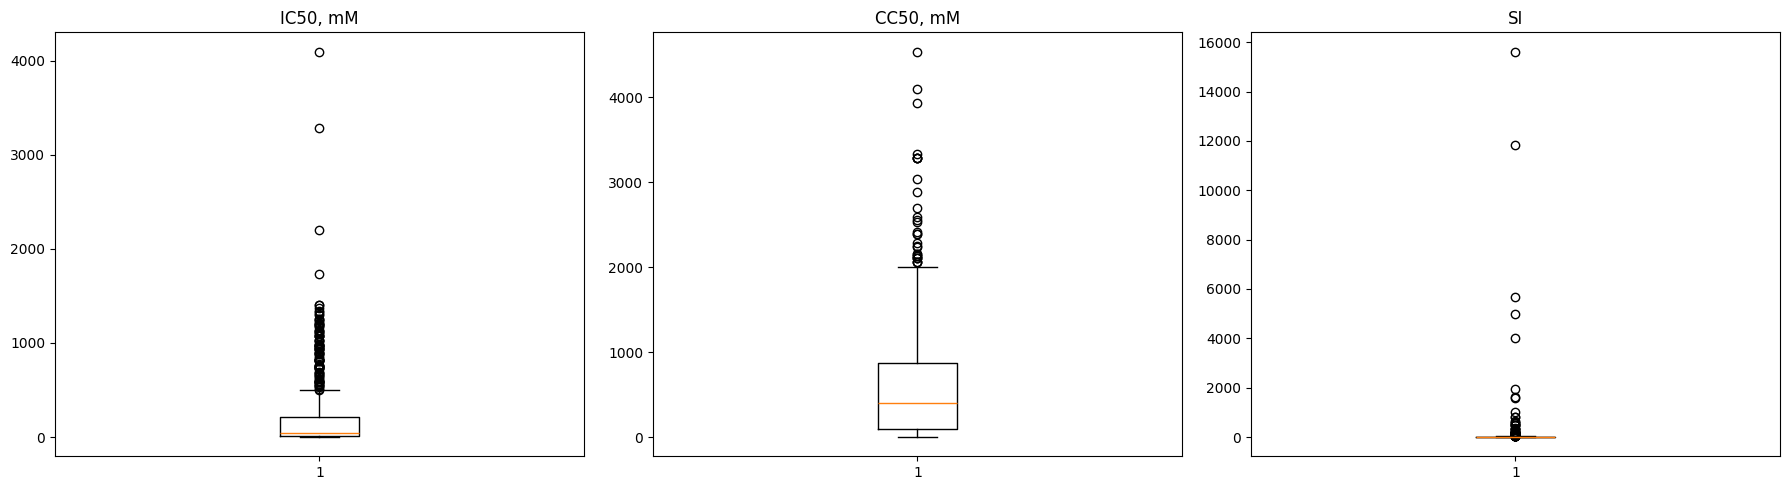

In [1023]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):

    ax.boxplot(df_train[target])

    ax.set_title(target)

plt.tight_layout()
plt.show()

Boxplot-анализ подтвердил наличие большого количества выбросов во всех целевых переменных.

Для IC50 наблюдается значительное число экстремально высоких значений, существенно превышающих межквартильный диапазон. Аналогичная ситуация наблюдается для CC50, однако распределение токсичности выглядит более стабильным и менее асимметричным по сравнению с IC50.

Наиболее выраженные выбросы характерны для индекса селективности SI. Большинство значений сосредоточено в области низких значений, однако присутствует небольшое количество экстремально больших наблюдений, достигающих значений свыше 15000. 


In [1024]:
df_train = df_train[df_train['SI'] < 4000].reset_index(drop=True)

Исключены экстремальные выбросы таргета SI >= 4000, которые вносят сильный шум 

In [1025]:
df_train[targets].describe().T

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",729.0,205.998873,370.862999,0.013341,13.383763,45.10721,212.363272,4095.188563
"CC50, mM",729.0,577.030899,636.029047,0.700808,99.999036,409.07776,876.365304,4538.976189
SI,729.0,33.634484,139.348100,0.011489,1.548405,4.00000,16.100000,1952.562500


In [1026]:
df_train[targets].skew()

IC50, mM    3.814411
CC50, mM    2.096186
SI          9.046235
dtype: float64

Анализ коэффициента асимметрии (skewness) показал, что все целевые переменные обладают выраженной правосторонней асимметрией распределения. Полученные результаты подтверждают необходимость применения преобразования квадратного корня (sqrt) перед обучением моделей, поскольку оно позволяет уменьшить асимметрию распределений, стабилизировать масштаб целевых переменных и снизить влияние выбросов, при этом сохраняя достаточную вариативность данных для эффективного обучения.  
  
Выбор sqrt вместо log1p обусловлен следующими причинами. Степень асимметрии переменных является умеренной, поэтому sqrt обеспечивает оптимальное сжатие, тогда как log1p может излишне «пережать» распределение. Переменные содержат значения менее 1 (например, минимум SI = 0.011), и sqrt сохраняет больше информации в этой области. Максимальные значения после sqrt сжимаются до диапазона 44-67, сохраняя различимость между большими значениями, тогда как log1p сжал бы их до 7.6-8.4, что привело бы к потере вариативности. Предварительная фильтрация уже удалила экстремальные выбросы, поэтому нет необходимости в агрессивном сжатии. Интерпретация результатов проще при использовании sqrt, так как обратное преобразование требует простого возведения в квадрат. Таким образом, sqrt — сбалансированное решение, обеспечивающее нормализацию без излишней потери информации.  

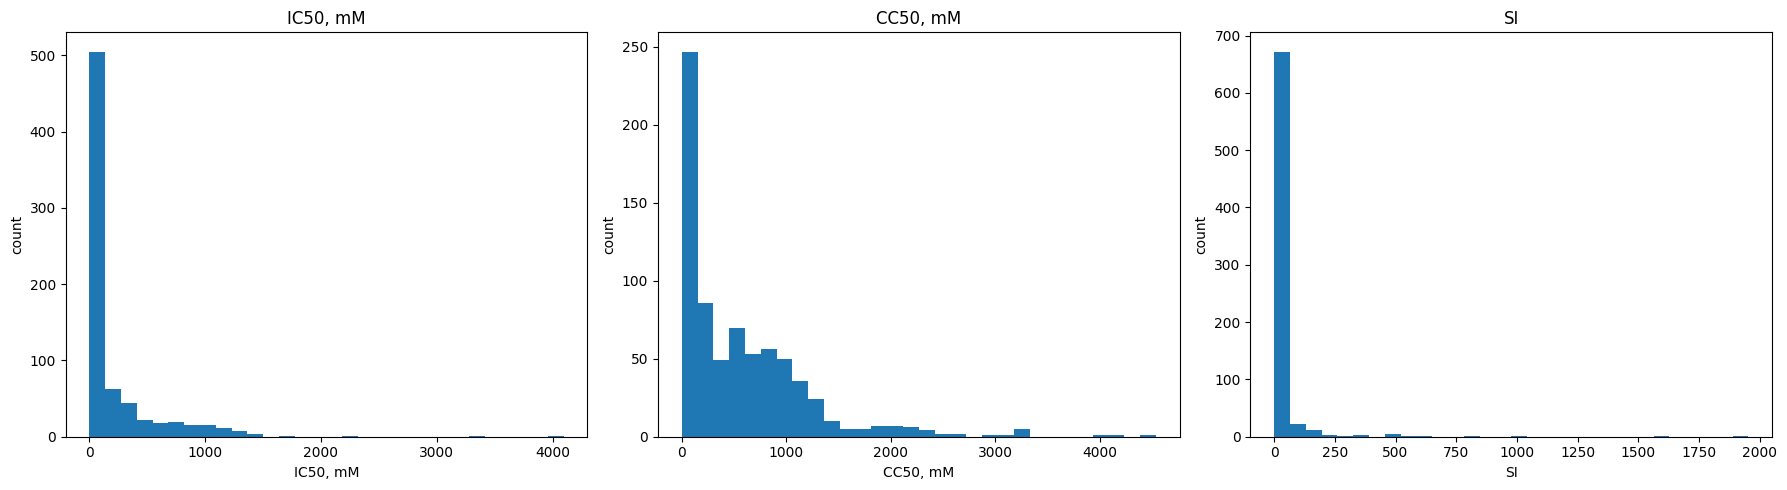

In [1027]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target in zip(axes, targets):

    ax.hist(df_train[target], bins=30)

    ax.set_title(target)
    ax.set_xlabel(target)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [1028]:
for target in targets:
    df_train[f"sqrt_{target}"] = np.sqrt(df_train[target])

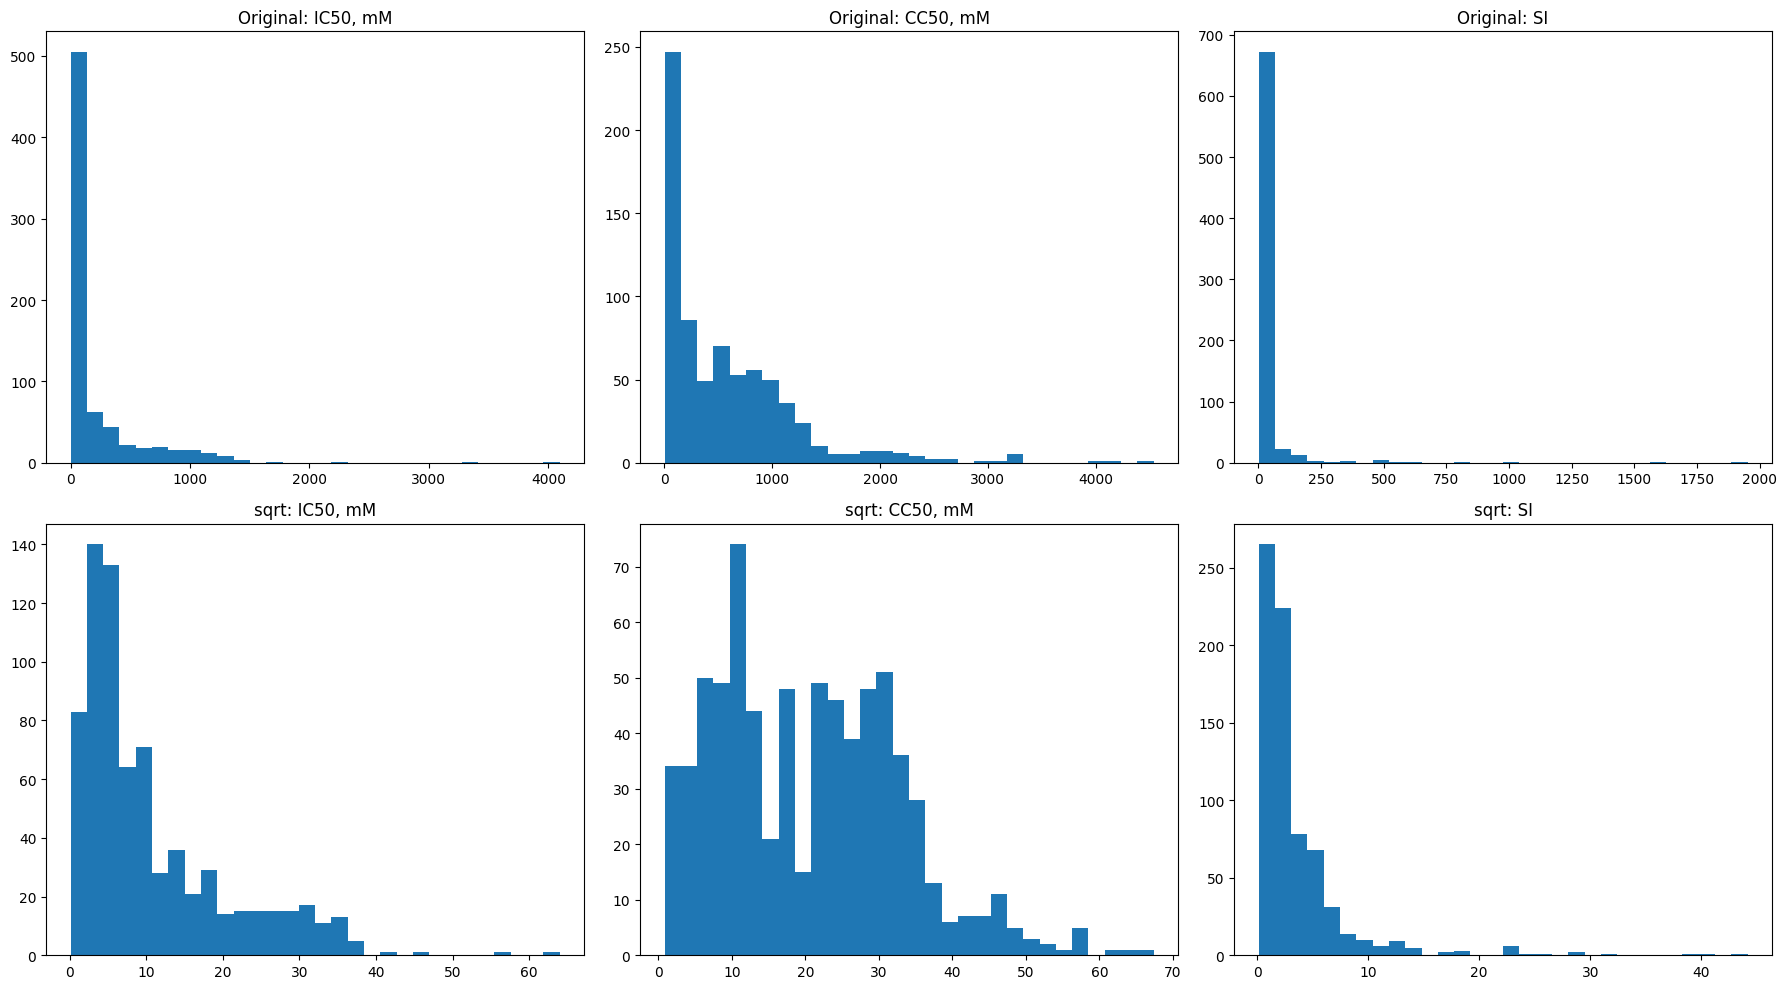

In [1029]:
log_targets = [
    f"sqrt_{t}"
    for t in targets
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, target in enumerate(targets):

    axes[0, i].hist(df_train[target], bins=30)
    axes[0, i].set_title(f"Original: {target}")

    axes[1, i].hist(df_train[f"sqrt_{target}"], bins=30)
    axes[1, i].set_title(f"sqrt: {target}")

plt.tight_layout()
plt.show()

In [1030]:
sqrt_targets = [f"sqrt_{target}" for target in targets]
df_train[sqrt_targets].skew()

sqrt_IC50, mM    1.498915
sqrt_CC50, mM    0.567636
sqrt_SI          4.391728
dtype: float64

Преобразование квадратного корня (sqrt) уменьшает асимметрию распределений и делает их ближе к нормальным, что потенциально улучшает стабильность и качество моделей регрессии

In [1031]:
train_with_engineered_features = df_train.copy()
test_with_engineered_features = df_test.copy()


train_with_engineered_features.to_csv("../data/processed/train_with_engineered_features.csv", index=False)
test_with_engineered_features.to_csv("../data/processed/test_with_engineered_features.csv", index=False)

## ГРУППА 1: Общие молекулярные свойства

In [1032]:
df_train[group_general_properties].describe().T

,count,mean,std,min,25%,50%,75%,max
qed,729.0,0.576984,0.215344,0.059567,0.442842,0.635801,0.743610,0.947265
SPS,729.0,29.521757,12.611116,9.545455,18.307692,29.281250,38.866667,60.272727
MolWt,729.0,355.196827,129.723082,110.156000,267.240000,321.917000,415.367000,904.777000
HeavyAtomMolWt,729.0,331.090556,124.637310,100.076000,249.127000,299.192000,392.147000,856.393000
ExactMolWt,729.0,354.866519,129.576577,110.073165,267.053158,321.137636,415.103143,904.248467
NumValenceElectrons,729.0,134.600823,47.443964,42.000000,104.000000,124.000000,156.000000,350.000000
MolLogP,729.0,3.496898,2.137276,-5.750700,2.466700,3.463400,4.583400,12.822200
MolMR,729.0,96.138141,34.984369,28.088500,74.021700,87.667200,112.899200,236.253400
TPSA,729.0,62.138148,46.620825,0.000000,29.460000,50.800000,83.760000,407.500000
LabuteASA,729.0,149.589902,53.561697,46.234269,115.073092,134.965517,175.240896,353.328713


Группа general_properties описывает базовые физико-химические характеристики молекул: массу, липофильность, полярность, площадь поверхности, количество гетероатомов и способность к образованию водородных связей. Большинство признаков имеют асимметричные распределения с длинными правыми хвостами, что характерно для химических дескрипторов. Особенно это заметно для MolWt, MolMR, TPSA, LabuteASA и NumRotatableBonds, где присутствуют молекулы с существенно большими значениями относительно основной массы выборки. Некоторые признаки (qed, FractionCSP3) распределены более компактно и ограничены фиксированными диапазонами. Также наблюдаются выбросы, однако они, вероятнее всего, отражают реальные особенности отдельных химических структур, а не ошибки данных.

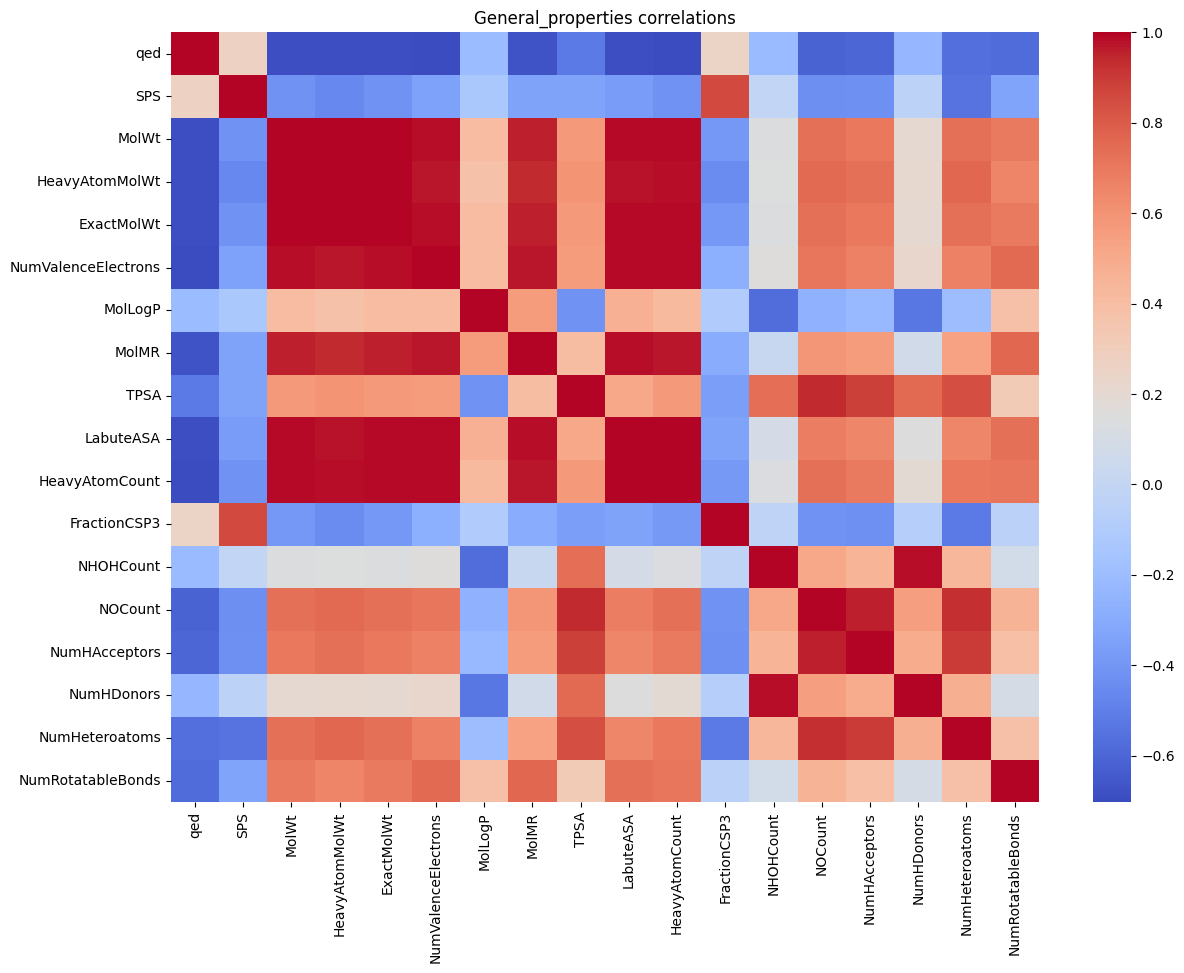

In [1033]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_train[group_general_properties].corr(),
    cmap="coolwarm"
)

plt.title("General_properties correlations")

plt.show()

Корреляционная матрица показывает выраженную мультиколлинеарность между признаками, связанными с размером и составом молекулы. Практически идеальные корреляции наблюдаются между MolWt, ExactMolWt, HeavyAtomMolWt, HeavyAtomCount и NumValenceElectrons, что объясняется тем, что все эти признаки описывают молекулярный размер и атомный состав. Высокие корреляции также присутствуют между MolMR, LabuteASA, TPSA и количеством гетероатомов. Кроме того, признаки водородных связей (NHOHCount, NumHDonors, NumHAcceptors) тесно связаны с TPSA и NumHeteroatoms. Таким образом, внутри группы присутствует значительная избыточность информации, и часть признаков потенциально может быть удалена при построении линейных моделей.

In [1034]:
for target in sqrt_targets:
    corr = (
        df_train[group_general_properties]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
NumRotatableBonds     -0.180423
MolLogP               -0.172440
MolMR                 -0.162501
LabuteASA             -0.131072
NumValenceElectrons   -0.126301
HeavyAtomCount        -0.112041
MolWt                 -0.106935
ExactMolWt            -0.106866
qed                    0.104779
FractionCSP3          -0.093831
dtype: float64

Корреляция с sqrt_CC50, mM:
MolMR                 -0.261650
LabuteASA             -0.257754
NumValenceElectrons   -0.254476
MolWt                 -0.252534
ExactMolWt            -0.252514
HeavyAtomCount        -0.252444
HeavyAtomMolWt        -0.247298
NumRotatableBonds     -0.183402
MolLogP               -0.182138
NHOHCount             -0.163887
dtype: float64

Корреляция с sqrt_SI:
FractionCSP3           0.211281
HeavyAtomMolWt        -0.138140
HeavyAtomCount        -0.127534
ExactMolWt            -0.125947
MolWt                 -0.125909
NumHeteroatoms        -0.117871
LabuteASA             -0.115208
NumHAcceptors         -0.

Корреляционный анализ признаков группы общих молекулярных свойств с трансформированными целевыми переменными показал умеренные линейные связи (|r| < 0.3).

Для sqrt(IC50) наиболее заметны отрицательные корреляции с NumRotatableBonds (r = -0.18), MolLogP (r = -0.17) и MolMR (r = -0.16). Положительная связь наблюдается только с qed (r = 0.10).

Для sqrt(CC50) отрицательные корреляции выражены сильнее: MolMR (r = -0.26), LabuteASA (r = -0.26), NumValenceElectrons (r = -0.25), MolWt и ExactMolWt (r ≈ -0.25).

Для sqrt(SI) наиболее интересна положительная корреляция с FractionCSP3 (r = 0.21), тогда как HeavyAtomMolWt (r = -0.14), HeavyAtomCount (r = -0.13) и ExactMolWt (r = -0.13) демонстрируют слабые отрицательные связи.

Несмотря на низкие абсолютные значения корреляций, признаки остаются информативными, поскольку зависимости в QSAR-задачах часто имеют нелинейный характер и будут улавливаться моделями машинного обучения.

In [1035]:
mass_corr_cols = [
    'ExactMolWt',
    'HeavyAtomMolWt',
    'NumValenceElectrons',
    'HeavyAtomCount',
    'NHOHCount'
]

df_train = df_train.drop(columns=mass_corr_cols, errors='ignore')

В результате анализа были выявлены практически полностью дублирующие друг друга дескрипторы молекулярной массы: ExactMolWt, HeavyAtomMolWt и MolWt. Поскольку коэффициенты корреляции между ними превышали r = 0.99, дескриптор MolWt был сохранён как наиболее универсальная и интерпретируемая характеристика размера молекулы, тогда как остальные признаки были удалены как избыточные.

Дополнительно были исключены дескрипторы NumValenceElectrons и HeavyAtomCount, поскольку они также демонстрировали чрезвычайно высокую корреляцию с молекулярной массой и площадью поверхности молекул (LabuteASA)  
  
Аналогичная ситуация наблюдалась для дескрипторов NHOHCount и NumHDonors, характеризующих способность молекулы выступать донором водородной связи. В связи с крайне высокой корреляцией между ними (r > 0.98) был сохранён более общий и широко используемый дескриптор NumHDonors.  

## ГРУППА 2: Электронные и зарядовые характеристики

### Электронно-зарядовые дескрипторы

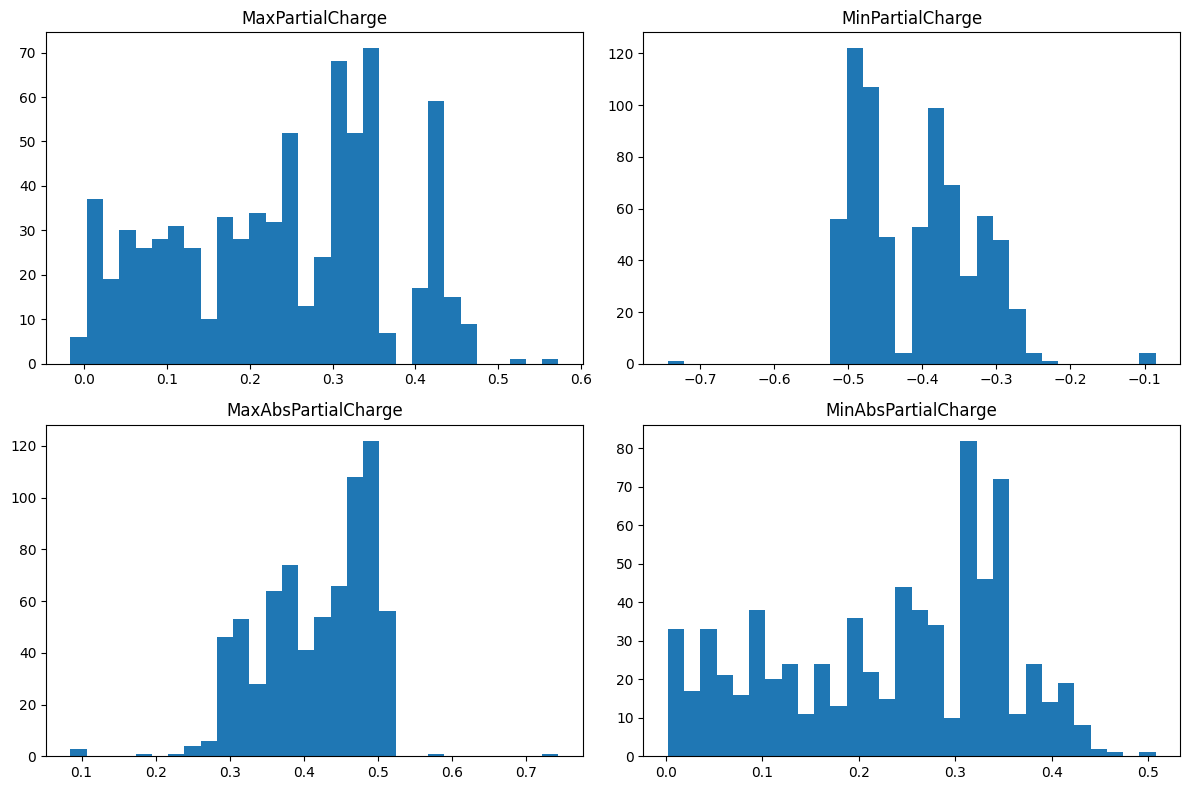

In [1036]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), group_electronic_charge):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Распределения признаков соответствуют их химическому смыслу: MaxPartialCharge характеризует наиболее электронодефицитные участки молекулы, тогда как MinPartialCharge описывает наиболее электроноизбыточные атомы.

In [1037]:
corr_electronic = (
    df_train[group_electronic_charge]
    .corr()
)

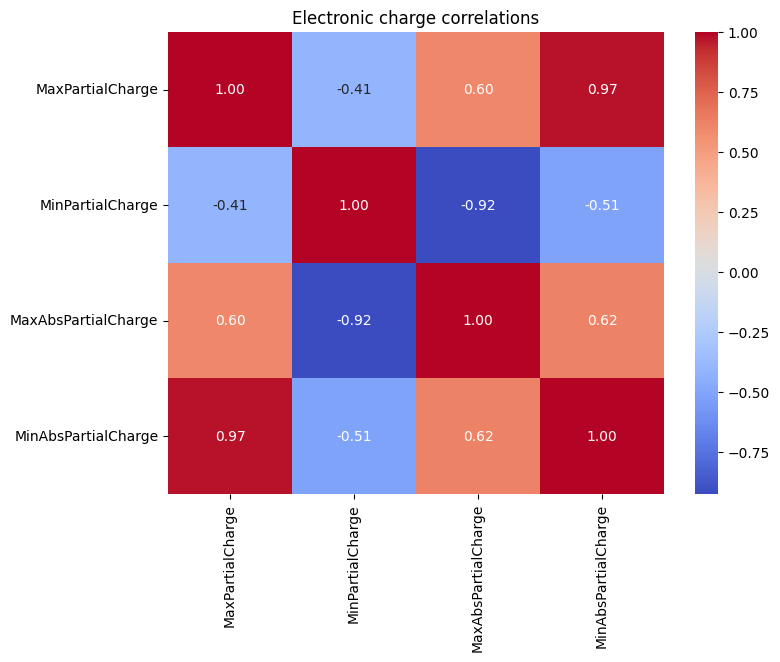

In [1038]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_electronic,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Electronic charge correlations")

plt.show()

Корреляционынй Анализ электронных и зарядовых дескрипторов показал наличие выраженной внутренней корреляции между признаками, особенно между MaxPartialCharge и MinAbsPartialCharge (r ≈ 0.97), а также между MinPartialCharge и MaxAbsPartialCharge (r ≈ -0.92). Это объясняется их математической зависимостью и отражает высокую степень мультиколлинеарности внутри группы.

In [1039]:
for target in sqrt_targets:
    corr = (
        df_train[group_electronic_charge]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
MaxPartialCharge       0.129208
MinAbsPartialCharge    0.117537
MaxAbsPartialCharge    0.060244
MinPartialCharge      -0.023869
dtype: float64

Корреляция с sqrt_CC50, mM:
MaxAbsPartialCharge   -0.094493
MinPartialCharge       0.086218
MinAbsPartialCharge   -0.065313
MaxPartialCharge      -0.061933
dtype: float64

Корреляция с sqrt_SI:
MaxPartialCharge      -0.078100
MinAbsPartialCharge   -0.067105
MaxAbsPartialCharge   -0.044166
MinPartialCharge       0.014737
dtype: float64


Корреляционный анализ с целевыми переменными (sqrt_IC50, sqrt_CC50 и sqrt_SI) показал слабые линейные зависимости для электронно-зарядовых дескрипторов (|r| < 0.15). Наибольшая корреляция с sqrt_IC50 наблюдалась для дескрипторов MaxPartialCharge (r = 0.129) и MinAbsPartialCharge (r = 0.118), тогда как для sqrt_CC50 максимальные по модулю значения корреляции не превышали 0.10. Для индекса селективности (sqrt_SI) линейные зависимости также оказались слабо выраженными.

Полученные результаты свидетельствуют об отсутствии сильного самостоятельного линейного влияния электронно-зарядовых характеристик на биологическую активность, цитотоксичность и селективность исследуемых соединений.

Тем не менее, данные дескрипторы могут содержать значимую нелинейную информацию, связанную с распределением электронной плотности и локальных зарядов в молекуле, что делает их потенциально полезными для ансамблевых методов машинного обучения, включая градиентный бустинг, случайный лес и другие нелинейные алгоритмы QSAR-моделирования.

### Электростатически-поверхностные дескрипторы (PEOE_VSA)

In [1040]:
df_train[group_peoe_vsa].describe().T

,count,mean,std,min,25%,50%,75%,max
PEOE_VSA1,729.0,12.849387,11.964958,0.0,5.316789,10.006437,15.160179,118.909965
PEOE_VSA10,729.0,8.457731,13.095621,0.0,0.000000,5.724986,11.667418,107.923797
PEOE_VSA11,729.0,5.007259,8.824696,0.0,0.000000,0.000000,5.783245,47.413913
PEOE_VSA12,729.0,3.599979,5.655472,0.0,0.000000,0.000000,5.907180,29.507868
PEOE_VSA13,729.0,1.177821,2.668923,0.0,0.000000,0.000000,0.000000,17.721539
PEOE_VSA14,729.0,3.014460,4.030730,0.0,0.000000,0.000000,5.969305,23.943886
PEOE_VSA2,729.0,6.199338,6.032239,0.0,0.000000,4.794537,9.589074,34.192377
PEOE_VSA3,729.0,3.052905,5.139812,0.0,0.000000,0.000000,4.794537,43.457663
PEOE_VSA4,729.0,3.032474,6.754800,0.0,0.000000,0.000000,0.000000,44.612417
PEOE_VSA5,729.0,1.720950,4.344651,0.0,0.000000,0.000000,0.000000,23.523770


Дескрипторы PEOE_VSA* имеют сильно асимметричные распределения с длинными правыми хвостами и большим количеством нулевых значений. Для части признаков (PEOE_VSA11–14) медиана равна нулю, что указывает на отсутствие соответствующих зарядовых областей у значительной части молекул. Одновременно признаки PEOE_VSA6–9 имеют высокие средние значения и присутствуют практически во всех соединениях. В распределениях наблюдаются выбросы, однако они, вероятнее всего, отражают реальные химические особенности отдельных молекул, а не ошибки данных, поэтому удаление выбросов на текущем этапе не требуется.

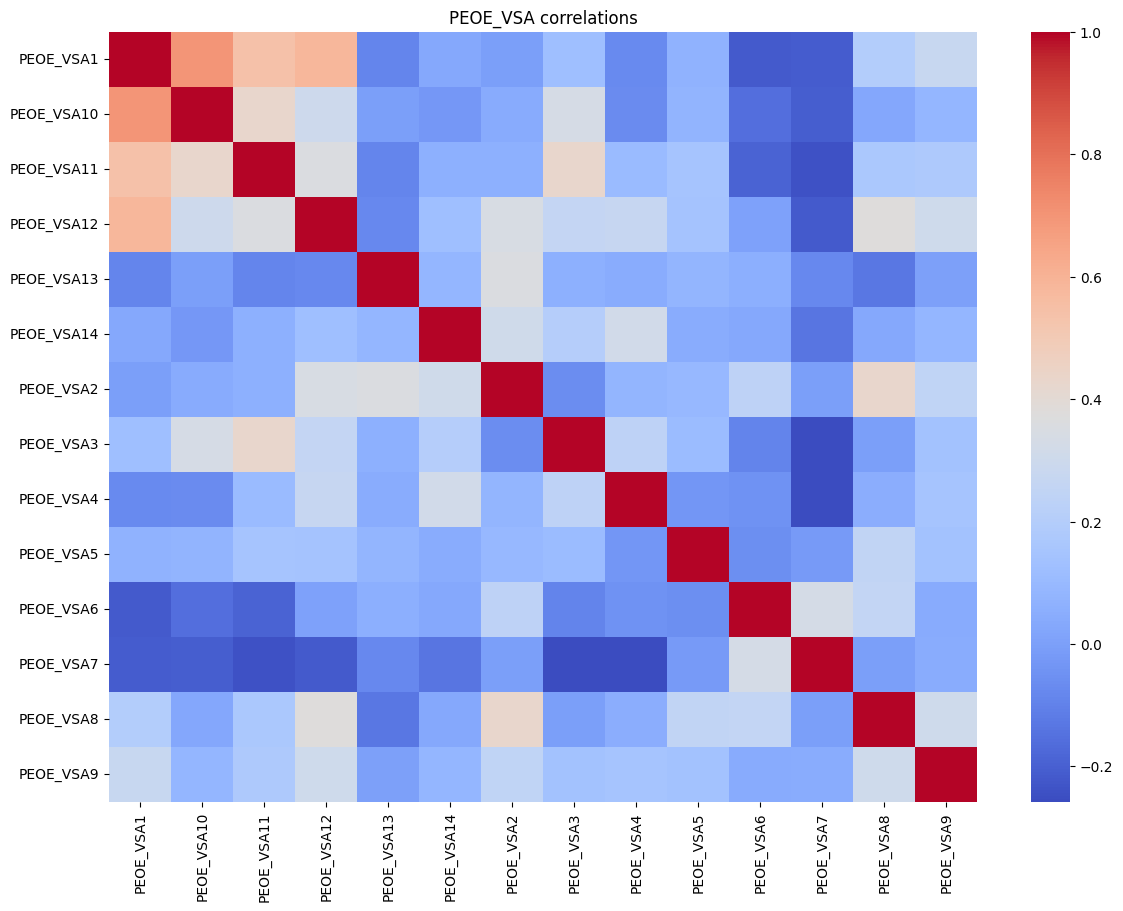

In [1041]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df_train[group_peoe_vsa].corr(),
    cmap="coolwarm"
)

plt.title("PEOE_VSA correlations")

plt.show()

Корреляционный анализ показал наличие умеренных взаимосвязей между отдельными PEOE_VSA-дескрипторами. Наиболее заметные корреляции наблюдаются между соседними бинами распределения поверхности, например между PEOE_VSA1 и PEOE_VSA10, а также между PEOE_VSA1 и PEOE_VSA12. При этом сильной мультиколлинеарности (|r| > 0.95) внутри группы не обнаружено. Это означает, что признаки содержат различающуюся информацию и могут быть сохранены для дальнейшего моделирования без дополнительного удаления.

In [1042]:
for target in sqrt_targets:
    corr = (
        df_train[group_peoe_vsa]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
PEOE_VSA7    -0.214054
PEOE_VSA6    -0.190723
PEOE_VSA4     0.098677
PEOE_VSA13    0.091994
PEOE_VSA9     0.050528
PEOE_VSA14    0.044273
PEOE_VSA12    0.025658
PEOE_VSA3    -0.023355
PEOE_VSA8    -0.016852
PEOE_VSA2    -0.016286
dtype: float64

Корреляция с sqrt_CC50, mM:
PEOE_VSA7    -0.232414
PEOE_VSA6    -0.200294
PEOE_VSA14   -0.121159
PEOE_VSA1    -0.102776
PEOE_VSA2    -0.087225
PEOE_VSA11   -0.070035
PEOE_VSA10   -0.069873
PEOE_VSA12   -0.066976
PEOE_VSA3    -0.059306
PEOE_VSA5    -0.022881
dtype: float64

Корреляция с sqrt_SI:
PEOE_VSA10   -0.108932
PEOE_VSA11   -0.095076
PEOE_VSA4    -0.094393
PEOE_VSA2    -0.086258
PEOE_VSA14   -0.081137
PEOE_VSA13   -0.080514
PEOE_VSA5    -0.059042
PEOE_VSA12   -0.040181
PEOE_VSA9    -0.037920
PEOE_VSA1    -0.035888
dtype: float64


Корреляционный анализ PEOE_VSA-дескрипторов с целевыми переменными (sqrt_IC50, sqrt_CC50 и sqrt_SI) показал преимущественно слабые и умеренные линейные зависимости. Наиболее выраженные отрицательные корреляции наблюдались для дескрипторов PEOE_VSA7 и PEOE_VSA6: с sqrt_IC50 значения коэффициентов составили −0.214 и −0.191 соответственно, а с sqrt_CC50 — −0.232 и −0.200. Для индекса селективности (sqrt_SI) линейные зависимости оказались менее выраженными (|r| < 0.11).

Полученные результаты могут указывать на то, что определённые участки молекулярной поверхности, характеризующиеся специфическим распределением частичных зарядов, связаны с биологической активностью и цитотоксичностью исследуемых соединений. При этом большинство PEOE_VSA-дескрипторов демонстрируют лишь слабые линейные корреляции с целевыми переменными.

Несмотря на это, дескрипторы семейства PEOE_VSA потенциально остаются информативными для нелинейных моделей машинного обучения, поскольку одновременно учитывают как распределение частичных зарядов, так и характеристики молекулярной поверхности, что может быть важно для описания межмолекулярных взаимодействий, проницаемости и связывания с биологическими мишенями.

## ГРУППА 3: Топологические и структурные дескрипторы

In [1043]:
df_train[group_topological_structural].describe().T

,count,mean,std,min,25%,50%,75%,max
AvgIpc,729.0,2.834597e+00,4.389915e-01,1.787472e+00,2.500517,2.842919,3.101827e+00,3.952629e+00
BalabanJ,729.0,1.827428e+00,4.483486e-01,2.338384e-07,1.502681,1.821840,2.063714e+00,3.793185e+00
BertzCT,729.0,7.755872e+02,4.510491e+02,1.283485e+02,418.368869,670.536976,1.029212e+03,2.263926e+03
HallKierAlpha,729.0,-1.946561e+00,1.414999e+00,-6.520000e+00,-2.960000,-1.640000,-8.000000e-01,1.400000e-01
Ipc,729.0,6.518744e+10,1.471589e+12,1.071072e+02,23085.729192,137964.042298,6.738953e+06,3.951781e+13
Kappa1,729.0,1.732827e+01,6.483623e+00,4.539509e+00,13.062128,15.975804,2.005714e+01,4.690862e+01
Kappa2,729.0,6.525522e+00,3.077581e+00,1.335792e+00,4.447829,5.773028,7.638889e+00,2.037498e+01
Kappa3,729.0,3.161998e+00,1.781820e+00,4.449853e-01,2.011431,2.745136,3.868056e+00,1.266626e+01
Chi0,729.0,1.799613e+01,6.435391e+00,5.560478e+00,13.742276,16.596012,2.100142e+01,4.576397e+01
Chi0n,729.0,1.478384e+01,5.229190e+00,4.112077e+00,11.369499,13.596900,1.675862e+01,3.598698e+01


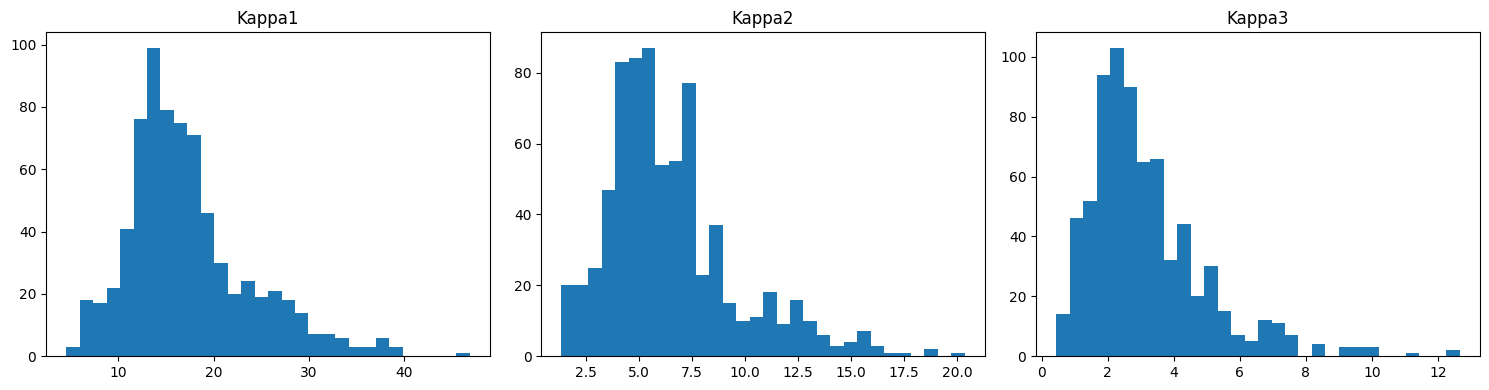

In [1044]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes.flatten(), group_kappa):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

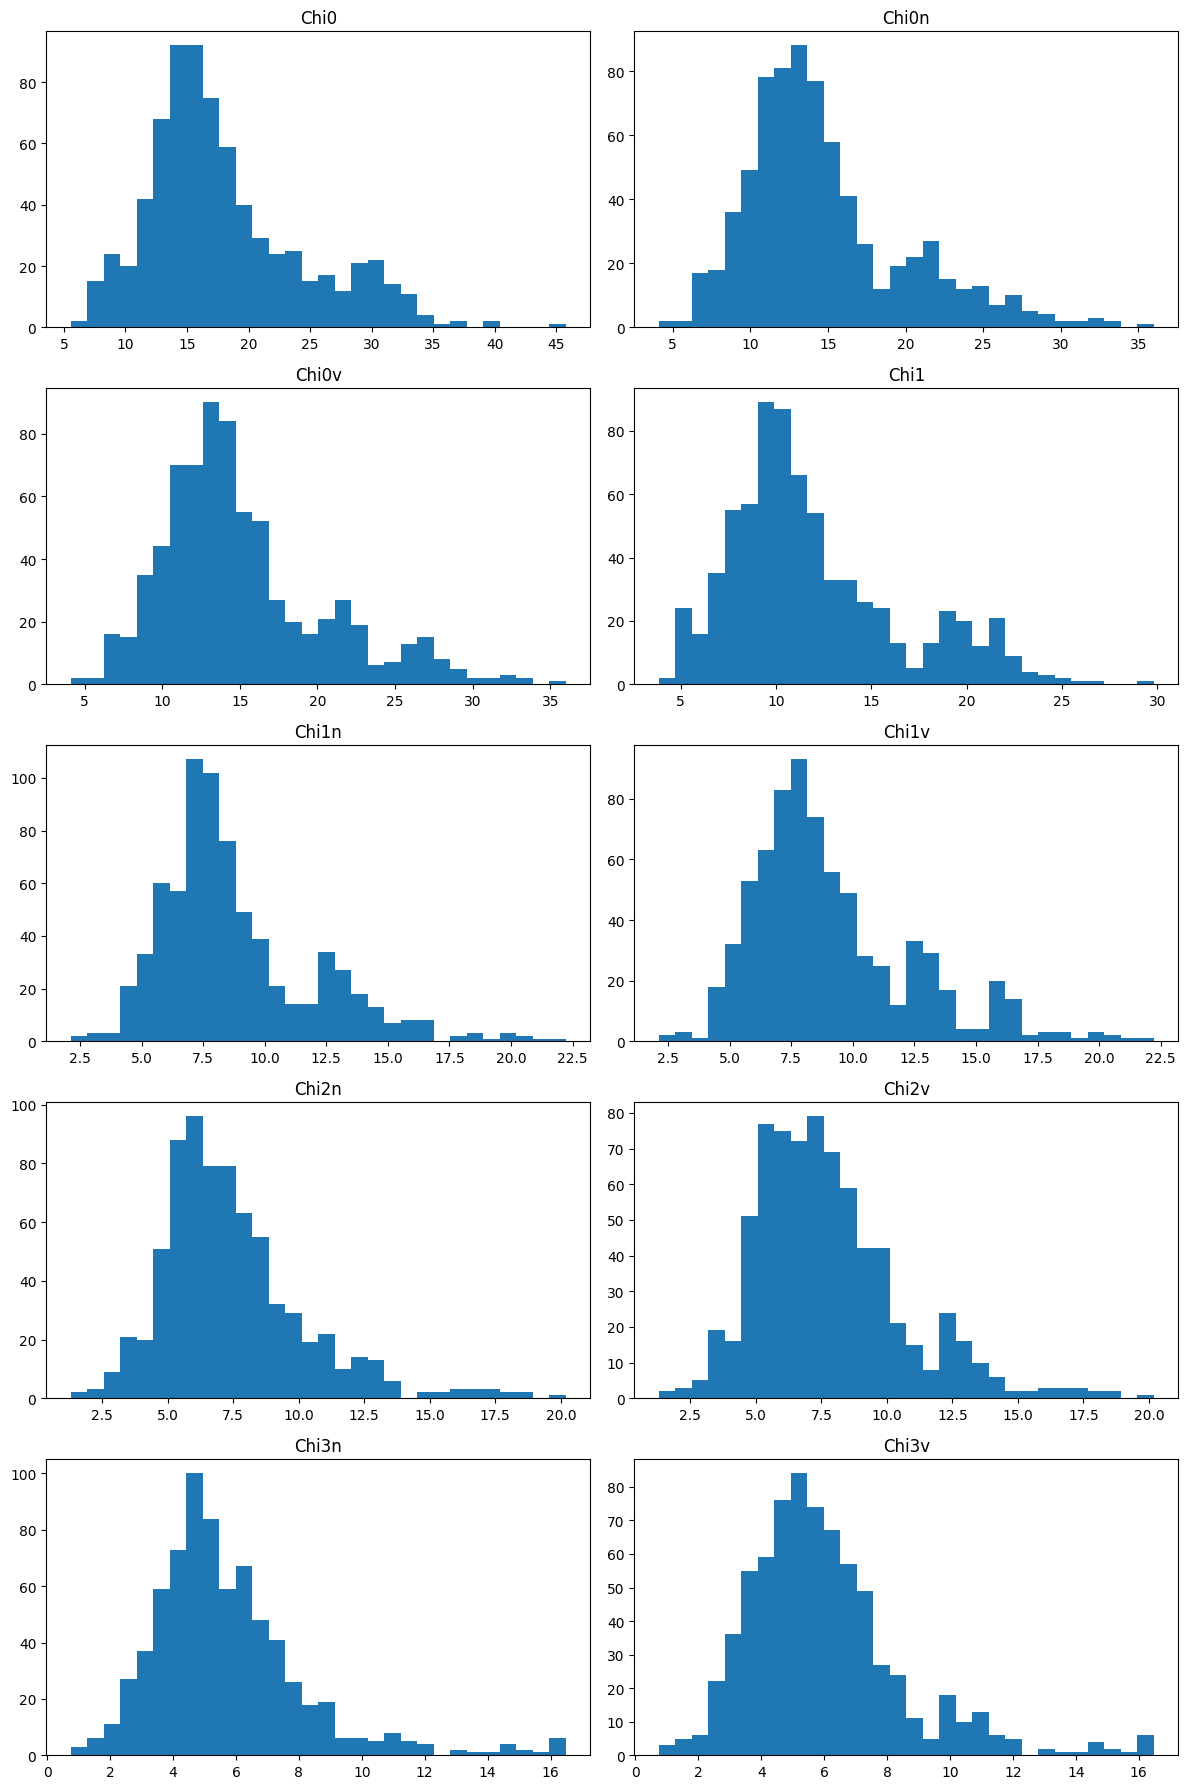

In [1045]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))

for ax, col in zip(axes.flatten(), group_chi):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Kappa1–Kappa3 и большинство Chi-дескрипторов обладают умеренно правосторонней асимметрией: основная масса соединений сосредоточена в низких значениях, при этом присутствуют длинные хвосты.  

Ipc имеет экстремально широкий диапазон значений (max ≈ 3.95e13) и сильнейшую асимметрию, что делает его нестабильным для линейных моделей без логарифмирования.  

BertzCT также имеет выраженные выбросы и отражает общую структурную сложность молекулы.    

Дескрипторы числа колец (RingCount, NumAromaticRings, NumSaturatedRings и др.) являются дискретными признаками с ограниченным диапазоном значений.

В целом группа содержит как непрерывные сильно асимметричные признаки, так и дискретные структурные счётчики.

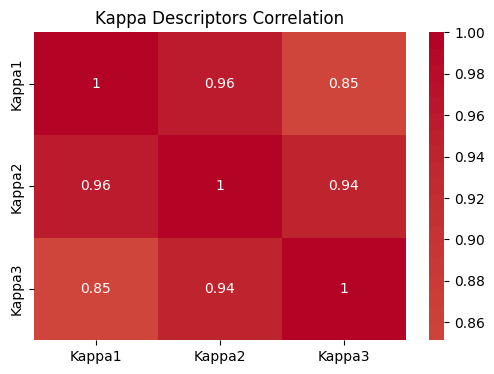

In [1046]:
corr_kappa = df_train[group_kappa].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_kappa,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Kappa Descriptors Correlation")
plt.show()

Анализ Kappa-дескрипторов показал очень высокую взаимную корреляцию между всеми признаками группы. Поскольку дескрипторы семейства Kappa описывают близкие структурные свойства, использование всех трёх одновременно может приводить к избыточности признакового пространства.

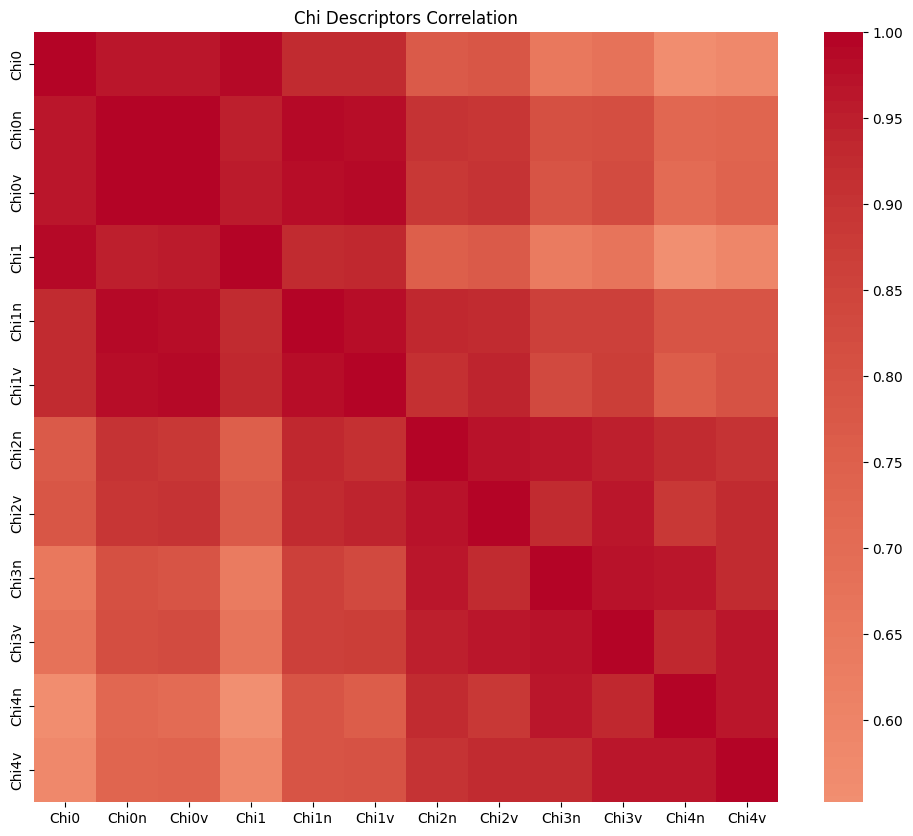

In [1047]:
corr_chi = df_train[group_chi].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_chi,
    cmap='coolwarm',
    center=0
)

plt.title("Chi Descriptors Correlation")
plt.show()

Матрица корреляции Chi-дескрипторов показала крайне высокую корреляцию практически между всеми признаками группы (во многих случаях r > 0.9).  
  
Наличие столь высокой корреляции свидетельствует о выраженной мультиколлинеарности внутри группы и существенном дублировании информации.  

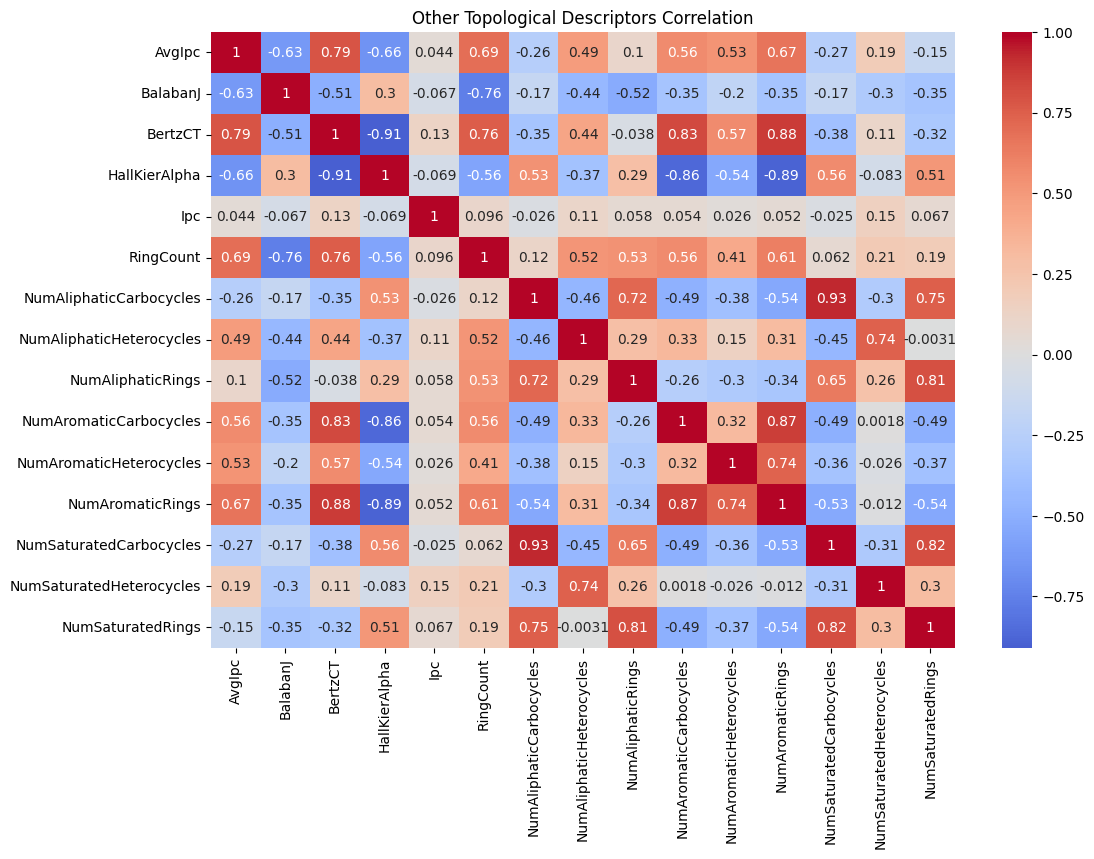

In [1048]:
group_other_topological = [
    'AvgIpc',
    'BalabanJ',
    'BertzCT',
    'HallKierAlpha',
    'Ipc',

    *group_ring_descriptors
]

corr_other_topological = (
    df_train[group_other_topological]
    .corr()
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_other_topological,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Other Topological Descriptors Correlation")
plt.show()

Анализ остальных топологических дескрипторов выявил как положительные, так и отрицательные взаимосвязи между признаками.Большинство признаков данной группы сохраняют самостоятельную химическую интерпретацию

In [1049]:
for target in sqrt_targets:
    corr = (
        df_train[group_topological_structural]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
NumSaturatedHeterocycles    0.222388
Chi2n                      -0.208832
NumAliphaticCarbocycles    -0.205867
Chi2v                      -0.205644
Chi4v                      -0.195456
Chi4n                      -0.194817
Chi3n                      -0.190266
NumSaturatedCarbocycles    -0.189519
Chi3v                      -0.189468
Chi1n                      -0.176066
dtype: float64

Корреляция с sqrt_CC50, mM:
Kappa3   -0.287918
Kappa2   -0.269135
Kappa1   -0.268285
Chi0     -0.259375
Chi1v    -0.256289
Chi0v    -0.255215
Chi0n    -0.252027
Chi1n    -0.249491
Chi1     -0.248391
Chi2v    -0.242724
dtype: float64

Корреляция с sqrt_SI:
RingCount                  -0.213411
NumAliphaticHeterocycles   -0.206308
NumAromaticRings           -0.190733
NumSaturatedHeterocycles   -0.182087
NumAromaticCarbocycles     -0.180318
BertzCT                    -0.177231
HallKierAlpha               0.173643
BalabanJ                    0.173404
AvgIpc                     -0.148

Полученные результаты показывают, что топологические дескрипторы, характеризующие форму, цикличность, разветвлённость и структурную сложность молекул, в большей степени связаны с цитотоксичностью (sqrt_CC50), чем с противовирусной активностью (sqrt_IC50) и индексом селективности (sqrt_SI). Наиболее выраженные корреляции с sqrt_CC50 наблюдались для дескрипторов семейства Kappa (Kappa1–Kappa3) и индексов Chi, где абсолютные значения коэффициентов достигали 0.29.

Для sqrt_IC50 наиболее заметные связи были выявлены для дескрипторов NumSaturatedHeterocycles, Chi2n и NumAliphaticCarbocycles, однако абсолютные значения коэффициентов корреляции также оставались умеренными (|r| < 0.23). В случае sqrt_SI наиболее выраженные зависимости наблюдались для параметров, связанных с количеством циклов и гетероциклических структур (RingCount, NumAliphaticHeterocycles, NumAromaticRings).

Несмотря на наличие отдельных умеренных корреляций, абсолютные значения коэффициентов в целом остаются относительно невысокими (|r| < 0.3), что свидетельствует об отсутствии сильных линейных зависимостей между топологическими характеристиками молекул и исследуемыми биологическими свойствами.

In [1050]:
topology_to_drop = [
   'Chi0',
   'Chi1',
   'Chi0n',
   'Chi1n',
]

df_train = df_train.drop(columns=topology_to_drop, errors='ignore')

Среди топологических индексов Chi наблюдалась выраженная мультиколлинеарность между признаками Chi0, Chi1, Chi0n, Chi1n, Chi0v и Chi1v. Для уменьшения избыточности были удалены Chi0, Chi1, Chi0n и Chi1n, тогда как valence-варианты (Chi0v, Chi1v) были сохранены, поскольку они содержат дополнительную информацию о валентных состояниях атомов и обладают большей химической информативностью для QSAR-моделирования.

## ГРУППА 4: Поверхностные дескрипторы (VSA)

- Признаки этой группы описывают распределение ван-дер-ваальсовой поверхности молекулы по 4м физико-химическим свойствам: липофильности (SlogP_VSA), поляризуемости (SMR_VSA) и электротопологическому состоянию в двух вариантах (EState_VSA и VSA_EState).

- Каждое подсемейство делит поверхность на бины — диапазоны значений свойства — и показывает, сколько площади приходится на каждый диапазон.

- Внутри каждого подсемейства сумма бинов примерно равна общей площади поверхности (LabuteASA). Это создаёт структурную мультиколлинеарность.

Базовая статистика и константы для VSA-признаков

In [1051]:
df_train[group_surface_vsa].describe().T

,count,mean,std,min,25%,50%,75%,max
SlogP_VSA1,729.0,6.151467,6.177415,0.000000,0.000000,5.316789,10.165653,33.158041
SlogP_VSA10,729.0,4.719198,7.301360,0.000000,0.000000,0.000000,5.687386,39.797093
SlogP_VSA11,729.0,3.819024,8.494051,0.000000,0.000000,0.000000,0.000000,57.495118
SlogP_VSA12,729.0,4.226148,8.173049,0.000000,0.000000,0.000000,11.336786,45.875452
SlogP_VSA2,729.0,33.849570,24.212213,0.000000,16.811545,28.100776,46.443339,213.138160
SlogP_VSA3,729.0,8.498491,7.712918,0.000000,4.736863,6.420822,12.841643,43.553732
SlogP_VSA4,729.0,11.805777,10.912698,0.000000,0.000000,11.332897,16.747887,52.255323
SlogP_VSA5,729.0,39.578294,26.286168,0.000000,21.484892,38.524930,50.451530,163.099895
SlogP_VSA6,729.0,32.222600,25.849078,0.000000,9.984809,29.848226,51.676258,126.698894
SlogP_VSA7,729.0,0.322368,1.455739,0.000000,0.000000,0.000000,0.000000,19.641034


In [1052]:
vsa_stats = pd.concat([
    df_train[group_surface_vsa].describe().T[['mean', 'std']],
    ((df_train[group_surface_vsa] == 0).mean()).rename('zeros')
], axis=1)

vsa_stats = vsa_stats.sort_values('mean')

vsa_near_zero = vsa_stats[
    (vsa_stats['zeros'] > 0.9) &
    (vsa_stats['std'] > 0)
].index.tolist()

print(f"Всего VSA-признаков: {len(group_surface_vsa)}")
print(f"Near-zero (>90% нулей): {len(vsa_near_zero)}")


Всего VSA-признаков: 41
Near-zero (>90% нулей): 3


Итог: 
- 41 признак.
- 3 near-zero бина с >90% нулей.

Вывод: 
- near-zero — кандидаты на удаление.

Корреляции внутри подсемейств VSA

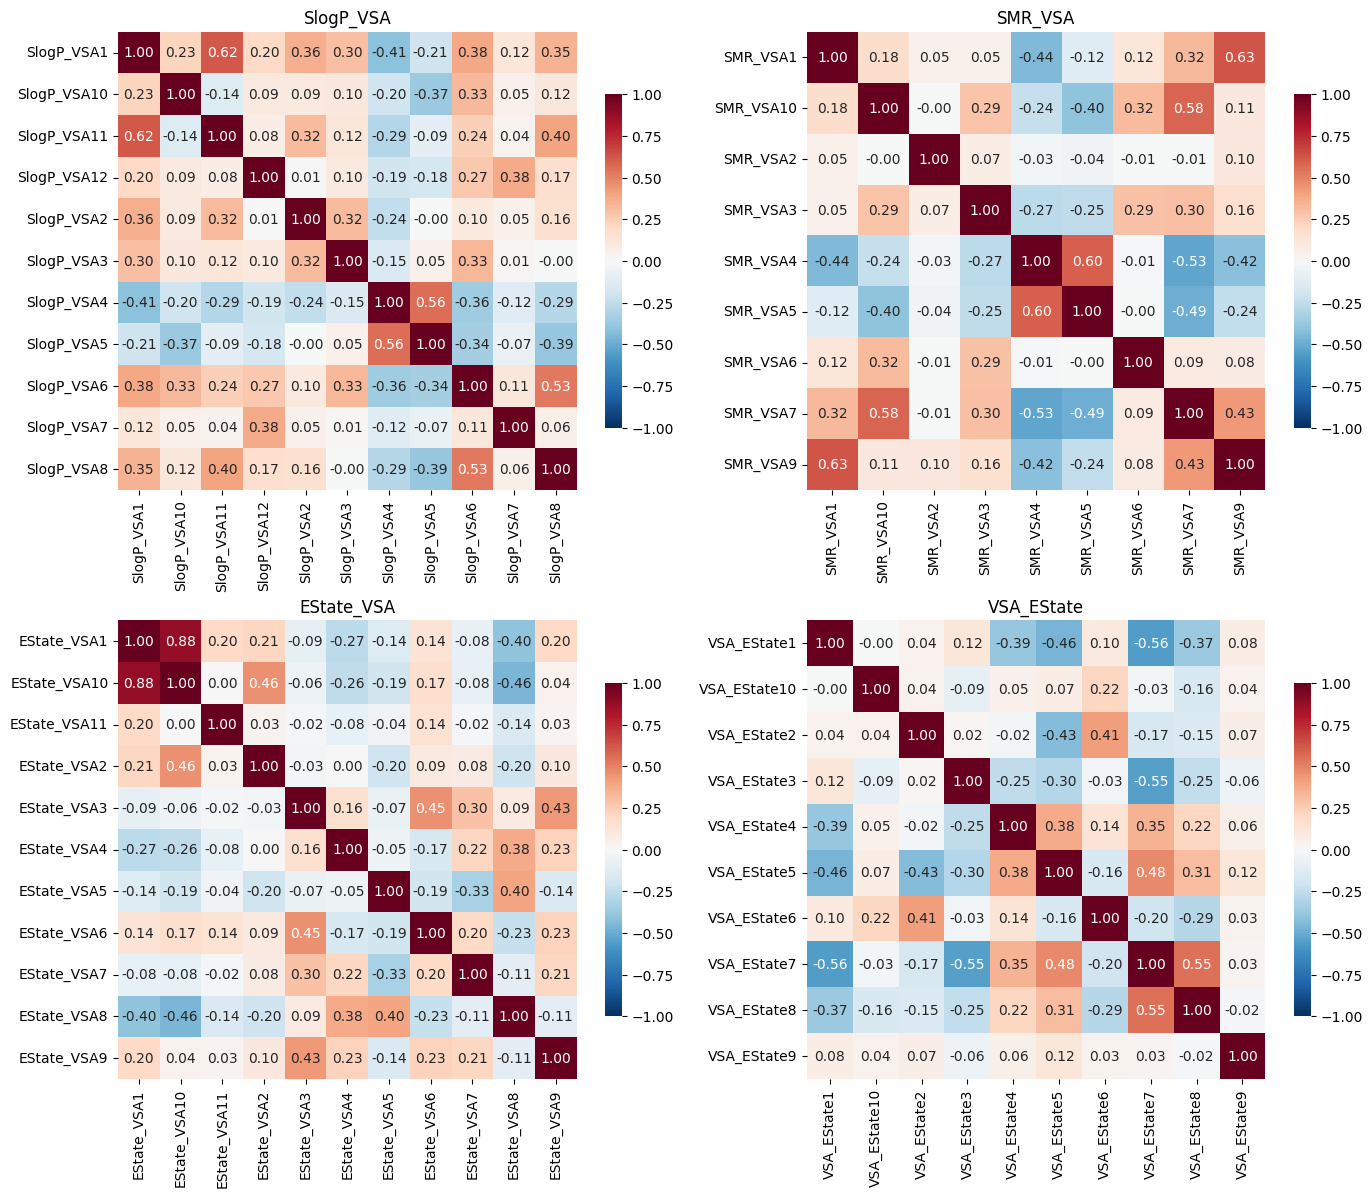

SlogP_VSA: пар с |r| > 0.8 нет
SMR_VSA: пар с |r| > 0.8 нет
EState_VSA: пар с |r| > 0.8 — 1
  EState_VSA1 - EState_VSA10 : 0.880
VSA_EState: пар с |r| > 0.8 нет


In [1053]:
vsa_subfamilies = {
    'SlogP_VSA': group_slogp_vsa,
    'SMR_VSA': group_smr_vsa,
    'EState_VSA': group_estate_vsa,
    'VSA_EState': group_vsa_estate,
}


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

vsa_intra_summary = {}

for idx, (name, cols) in enumerate(vsa_subfamilies.items()):
    cols_in_data = [c for c in cols if c in df_train.columns]
    if len(cols_in_data) < 2:
        continue
    corr = df_train[cols_in_data].corr()
    sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, annot=True, fmt='.2f',
                ax=axes[idx], cbar_kws={'shrink': 0.7})
    axes[idx].set_title(name)

    high = []
    for i in range(len(corr.columns)):
        for j in range(i + 1, len(corr.columns)):
            r = corr.iloc[i, j]
            if abs(r) > 0.8:
                high.append((corr.columns[i], corr.columns[j], round(r, 3)))
    vsa_intra_summary[name] = high

plt.tight_layout()
plt.show()

for name, pairs in vsa_intra_summary.items():
    if pairs:
        print(f"{name}: пар с |r| > 0.8 — {len(pairs)}")
        for a, b, r in pairs:
            print(f"  {a} - {b} : {r:.3f}")
    else:
        print(f"{name}: пар с |r| > 0.8 нет")

Итог :
- внутри каждого подсемейства бины слабо скоррелированы.
- Единственная пара с |r|>0.8 — EState_VSA1 и EState_VSA10 (0.879).



Корреляции между подсемействами VSA

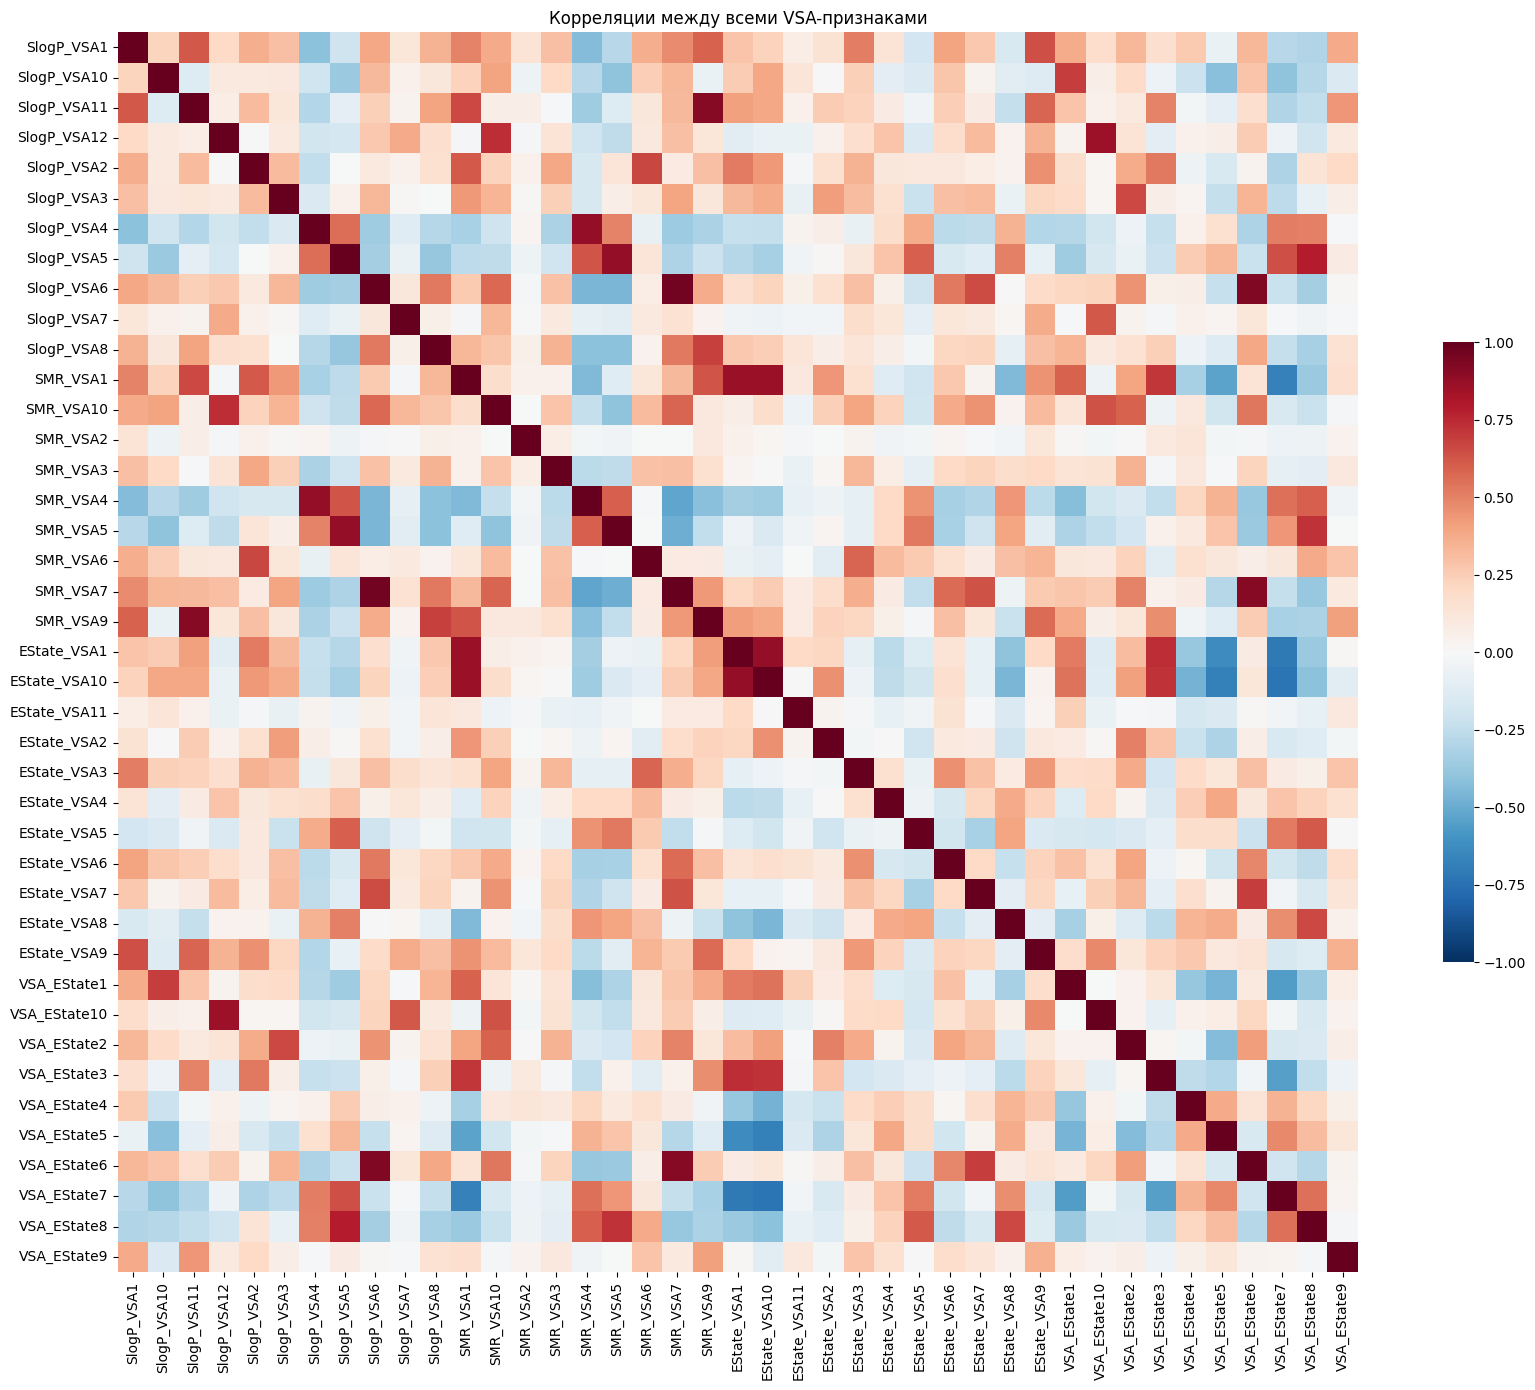

Межсемейных пар с |r| > 0.8: 9


In [1054]:
vsa_corr = df_train[group_surface_vsa].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(vsa_corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.5})
plt.title('Корреляции между всеми VSA-признаками')
plt.tight_layout()
plt.show()

cross_high = []
for i in range(len(vsa_corr.columns)):
    for j in range(i + 1, len(vsa_corr.columns)):
        r = vsa_corr.iloc[i, j]
        if abs(r) > 0.8:
            a, b = vsa_corr.columns[i], vsa_corr.columns[j]
            fam_a = [k for k, v in vsa_subfamilies.items() if a in v][0]
            fam_b = [k for k, v in vsa_subfamilies.items() if b in v][0]
            if fam_a != fam_b:
                cross_high.append((a, b, round(r, 3)))

if cross_high:
    print(f"Межсемейных пар с |r| > 0.8: {len(cross_high)}")
else:
    print("Межсемейных пар с |r| > 0.8 нет")

Итог :
- 9 межсемейных пар с |r|>0.8, самая сильная — SlogP_VSA6 и SMR_VSA7 (0.962).
- Химически ожидаемо: липофильные участки часто поляризуемы.


Корреляции near-zero бинов с лог-таргетами (перед удалением)

In [1055]:
if vsa_near_zero:
    near_zero_corr = pd.DataFrame(index=vsa_near_zero, columns=['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI'], dtype=float)
    for col in vsa_near_zero:
        for t in ['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI']:
            near_zero_corr.loc[col, t] = df_train[col].corr(df_train[t])
    print("Near-zero бины — корреляции с лог-таргетами:")
    print(near_zero_corr.to_string())

Near-zero бины — корреляции с лог-таргетами:
              sqrt_IC50, mM  sqrt_CC50, mM   sqrt_SI
SMR_VSA2          -0.022316      -0.027747  0.067630
EState_VSA11       0.088613       0.041001 -0.057861
SlogP_VSA7        -0.050516      -0.088634  0.038020


Анализ дескрипторов, соответствующих near-zero bin-группам (SMR_VSA2, EState_VSA11, SlogP_VSA7), показал крайне слабые линейные корреляции с исследуемыми биологическими параметрами (sqrt_IC50, sqrt_CC50 и sqrt_SI). Абсолютные значения коэффициентов корреляции во всех случаях не превышали 0.1, что свидетельствует об отсутствии выраженной линейной связи между данными признаками и целевыми переменными.

Вывод: 
- Удаление 3 near-zero бинов подтверждено, значимой информации о таргетах они не несут.

Корреляция оставшихся VSA с лог-таргетами

In [1056]:
vsa_keep_final = [c for c in group_surface_vsa if c not in vsa_near_zero]

for target in sqrt_targets:
    corr = (
        df_train[vsa_keep_final]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
VSA_EState4   -0.253931
SlogP_VSA5    -0.226473
EState_VSA8   -0.207939
SMR_VSA4      -0.192968
EState_VSA5   -0.190863
VSA_EState8   -0.187786
VSA_EState7   -0.175706
SMR_VSA5      -0.165079
VSA_EState1    0.161128
SlogP_VSA4    -0.136198
dtype: float64

Корреляция с sqrt_CC50, mM:
SlogP_VSA3    -0.202800
SMR_VSA7      -0.186505
EState_VSA2   -0.184411
SlogP_VSA1    -0.174980
VSA_EState4   -0.168022
SlogP_VSA6    -0.164078
VSA_EState6   -0.156675
VSA_EState2   -0.154622
SMR_VSA10     -0.148893
EState_VSA4   -0.145509
dtype: float64

Корреляция с sqrt_SI:
SMR_VSA7      -0.216318
SlogP_VSA6    -0.200141
VSA_EState6   -0.180355
SMR_VSA5       0.134383
VSA_EState8    0.133985
VSA_EState1   -0.127421
SlogP_VSA8    -0.126586
SlogP_VSA10   -0.122556
SMR_VSA4       0.122324
EState_VSA6   -0.117493
dtype: float64


Полученные результаты показывают, что дескрипторы семейств VSA_EState, SlogP_VSA, SMR_VSA и EState_VSA, отражающие сочетание поверхностных, липофильных, электронных и стерических характеристик молекулы, демонстрируют преимущественно слабые и умеренные корреляции с исследуемыми биологическими параметрами.

Наиболее выраженные зависимости с sqrt_IC50 наблюдались для дескрипторов VSA_EState4 (r = −0.254), SlogP_VSA5 (r = −0.226) и EState_VSA8 (r = −0.208), что может свидетельствовать о влиянии распределения электронной плотности, липофильности и доступной поверхности молекулы на противовирусную активность соединений.

Для sqrt_CC50 наиболее заметные отрицательные корреляции были выявлены для SlogP_VSA3 (r = −0.203), SMR_VSA7 (r = −0.187) и EState_VSA2 (r = −0.184), что указывает на возможную связь поверхностных липофильных и стерических характеристик с цитотоксичностью исследуемых молекул.

В случае sqrt_SI наиболее выраженные корреляции наблюдались для SMR_VSA7 (r = −0.216), SlogP_VSA6 (r = −0.200) и VSA_EState6 (r = −0.180). Это может свидетельствовать о влиянии пространственного распределения липофильности и электронных свойств на селективность соединений.

Удаление

In [1057]:
vsa_removed_cols = vsa_near_zero

print(f"VSA: было {len(group_surface_vsa)}, удалено {len(vsa_removed_cols)}, осталось {len(vsa_keep_final)}")

df_train = df_train.drop(columns=vsa_removed_cols, errors='ignore')

VSA: было 41, удалено 3, осталось 38


Итог: 
- VSA_EState4 — лидер по обоим таргетам (log_IC50: -0.235, log_CC50: -0.170). SlogP_VSA5 и SMR_VSA5 также в топе. Все значимые корреляции отрицательные: большая площадь в этих бинах связана с повышенной активностью и токсичностью.

Вывод: 
- оставшиеся 38 признаков информативны. Электротопологические бины (VSA_EState4, EState_VSA2) и липофильные бины (SlogP_VSA3, SlogP_VSA5) — ключевые для предсказания. Удаление трёх near-zero бинов не затронуло важные признаки.

## ГРУППА 5: Функциональные группы

- Признаки группы функциональных групп показывают наличие и количество конкретных химических фрагментов в молекуле: колец (бензол, пиридин, имидазол), карбонильных групп (кетоны, эфиры, амиды), азотсодержащих (амины, нитро, нитрилы), серосодержащих (сульфиды, сульфоны), галогенов и других.
- Большинство — счётчики (сколько раз группа встречается в молекуле), некоторые — бинарные флаги.

- Наличие определённых групп усиливает или ослабляет активность, меняет токсичность, влияет на растворимость.

- Особенность: возможная иерархичность.

Базовая статистика

In [ ]:
df_train[group_functional_groups].describe().T

,count,mean,std,min,25%,50%,75%,max
fr_Al_COO,729.0,0.057613,0.233170,0.0,0.0,0.0,0.0,1.0
fr_Al_OH,729.0,0.419753,1.082805,0.0,0.0,0.0,0.0,12.0
fr_Al_OH_noTert,729.0,0.322359,1.038573,0.0,0.0,0.0,0.0,12.0
fr_ArN,729.0,0.015089,0.132775,0.0,0.0,0.0,0.0,2.0
fr_Ar_COO,729.0,0.001372,0.037037,0.0,0.0,0.0,0.0,1.0
fr_Ar_N,729.0,0.581619,1.286764,0.0,0.0,0.0,0.0,12.0
fr_Ar_NH,729.0,0.031550,0.174919,0.0,0.0,0.0,0.0,1.0
fr_Ar_OH,729.0,0.189300,0.766644,0.0,0.0,0.0,0.0,8.0
fr_COO,729.0,0.058985,0.235758,0.0,0.0,0.0,0.0,1.0
fr_COO2,729.0,0.058985,0.235758,0.0,0.0,0.0,0.0,1.0


Анализ fragment-based дескрипторов показал, что большинство признаков характеризуются сильно асимметричным распределением и высокой долей нулевых значений, что отражает редкое присутствие отдельных химических фрагментов в исследуемом наборе соединений. Наиболее распространёнными структурными элементами оказались ароматические, бициклические и кислород- и азотсодержащие фрагменты, характерные для drug-like молекул и гетероциклических соединений.

Для ряда дескрипторов наблюдалась высокая разреженность и низкая вариабельность, что может ограничивать их информативность при построении линейных моделей. Вместе с тем подобные sparse-признаки потенциально могут быть полезны для нелинейных алгоритмов QSAR-моделирования, способных выявлять сложные структурно-биологические взаимосвязи.

### Анализ частоты встречаемости 

In [1059]:
fr_stats = (
    pd.DataFrame({
        'col': group_functional_groups,
        'mean': df_train[group_functional_groups].mean().values,
        'std': df_train[group_functional_groups].std().values
    })
    .sort_values('mean')
)

rare_threshold = 0.01
suspect_threshold = 0.03

fr_very_rare = fr_stats[fr_stats['mean'] <= rare_threshold]['col'].tolist()
fr_suspect = fr_stats[(fr_stats['mean'] > rare_threshold) & (fr_stats['mean'] <= suspect_threshold)]['col'].tolist()

print(f"Очень редкие (<= 1%): {len(fr_very_rare)}")
print(fr_very_rare)
print(f"\nПодозрительные (1% – 3%): {len(fr_suspect)}")
print(fr_suspect)

Очень редкие (<= 1%): 14
['fr_Ar_COO', 'fr_HOCCN', 'fr_oxazole', 'fr_term_acetylene', 'fr_tetrazole', 'fr_hdrzine', 'fr_epoxide', 'fr_aldehyde', 'fr_guanido', 'fr_nitrile', 'fr_amidine', 'fr_urea', 'fr_oxime', 'fr_azo']

Подозрительные (1% – 3%): 10
['fr_sulfone', 'fr_nitro_arom_nonortho', 'fr_sulfonamd', 'fr_nitro_arom', 'fr_ArN', 'fr_alkyl_carbamate', 'fr_priamide', 'fr_piperzine', 'fr_nitro', 'fr_pyridine']


Дополнительный анализ частоты встречаемости признаков показал, что 14 дескрипторов присутствуют менее чем у 1% соединений выборки. Такие признаки обладают крайне низкой вариабельностью и потенциально могут приводить к статистически нестабильным разбиениям и повышенному риску переобучения, вследствие чего были исключены из дальнейшего моделирования. Ещё 10 редких дескрипторов с частотой встречаемости от 1% до 3% были сохранены, поскольку они могут содержать полезную структурную информацию для нелинейных алгоритмов QSAR-моделирования.

Полученные результаты подтверждают высокую структурную неоднородность исследуемого набора молекул и указывают на целесообразность использования ансамблевых и других нелинейных методов машинного обучения, способных эффективно работать с sparse-признаками и сложными нелинейными взаимосвязями между химической структурой и биологической активностью.

### Анализ иерархических взаимосвязей

In [1060]:
hierarchical_pairs = [
    ('fr_ketone_Topliss', 'fr_ketone'),
    ('fr_nitro_arom_nonortho', 'fr_nitro_arom'),
    ('fr_nitro_arom', 'fr_nitro'),
    ('fr_phenol_noOrthoHbond', 'fr_phenol'),
    ('fr_Al_OH_noTert', 'fr_Al_OH'),
    ('fr_C_O_noCOO', 'fr_C_O'),
    ('fr_Al_COO', 'fr_COO'),
    ('fr_Ar_COO', 'fr_COO'),
    ('fr_priamide', 'fr_amide'),
    ('fr_aniline', 'fr_Ar_NH'),
    ('fr_pyridine', 'fr_ArN'),
    ('fr_piperdine', 'fr_NH0'),
]

strict_hierarchy = []
nonstrict_hierarchy = []
skipped_pairs = []

for fr_A, fr_B in hierarchical_pairs:
    if fr_A not in group_functional_groups or fr_B not in group_functional_groups:
        continue
    mask_A = df_train[fr_A] > 0
    mask_B = df_train[fr_B] > 0
    total_A = mask_A.sum()
    if total_A == 0:
        skipped_pairs.append((fr_A, fr_B))
        continue
    violations = (mask_A & ~mask_B).sum()
    rate = violations / total_A
    if rate == 0:
        strict_hierarchy.append(fr_A)
    else:
        nonstrict_hierarchy.extend([fr_A, fr_B])

fr_hierarchy_remove = strict_hierarchy
fr_nonstrict_keep = list(set(nonstrict_hierarchy))

print(f"Строгая иерархия, признаков: {len(strict_hierarchy)}")
print(f"Нестрогая иерархия, признаков: {len(nonstrict_hierarchy)}")
if skipped_pairs:
    print(f"Пропущено (нет примеров): {len(skipped_pairs)}")

Строгая иерархия, признаков: 10
Нестрогая иерархия, признаков: 4


Результаты анализа иерархических взаимосвязей между fragment-based дескрипторами показали наличие 10 пар признаков со строгой вложенностью, при которой присутствие более специфического фрагмента всегда сопровождалось присутствием более общего дескриптора. Такие признаки являются структурно избыточными и могут рассматриваться как частные случаи более общих химических паттернов. В связи с этим специализированные дескрипторы со строгой иерархией были исключены из дальнейшего анализа для снижения избыточности признакового пространства.

Дополнительно было выявлено 4 признака, демонстрирующих нестрогую иерархическую зависимость. Для данных дескрипторов наблюдались отдельные нарушения вложенности, что указывает на наличие более сложных структурных взаимосвязей и потенциально самостоятельной химической информации. Такие признаки были сохранены для дальнейшего моделирования.

Итог:
- 13 предполагаемых иерархических пар (специфичная группа "вложена" в общую):
    -  10 строгих (специфичная группа всегда вложена в общую) пар -> 10 признаков кандидаты на удаление.
    - 2 не строгих пар -> 4 кандидата остаться.
    - 1 пара пропущена : fr_prisulfonamd и fr_sulfonamd. Оба признака — константы или редкие — выставлены на удаление ранее.

Вывод :
- в 10ти парах : специфичные признаки удалить, оставить общие (больше примеров, устойчивее статистика).
- 2 нестрогие пары оставить — химически это разные группы.

### Корреляции между fr-признаками

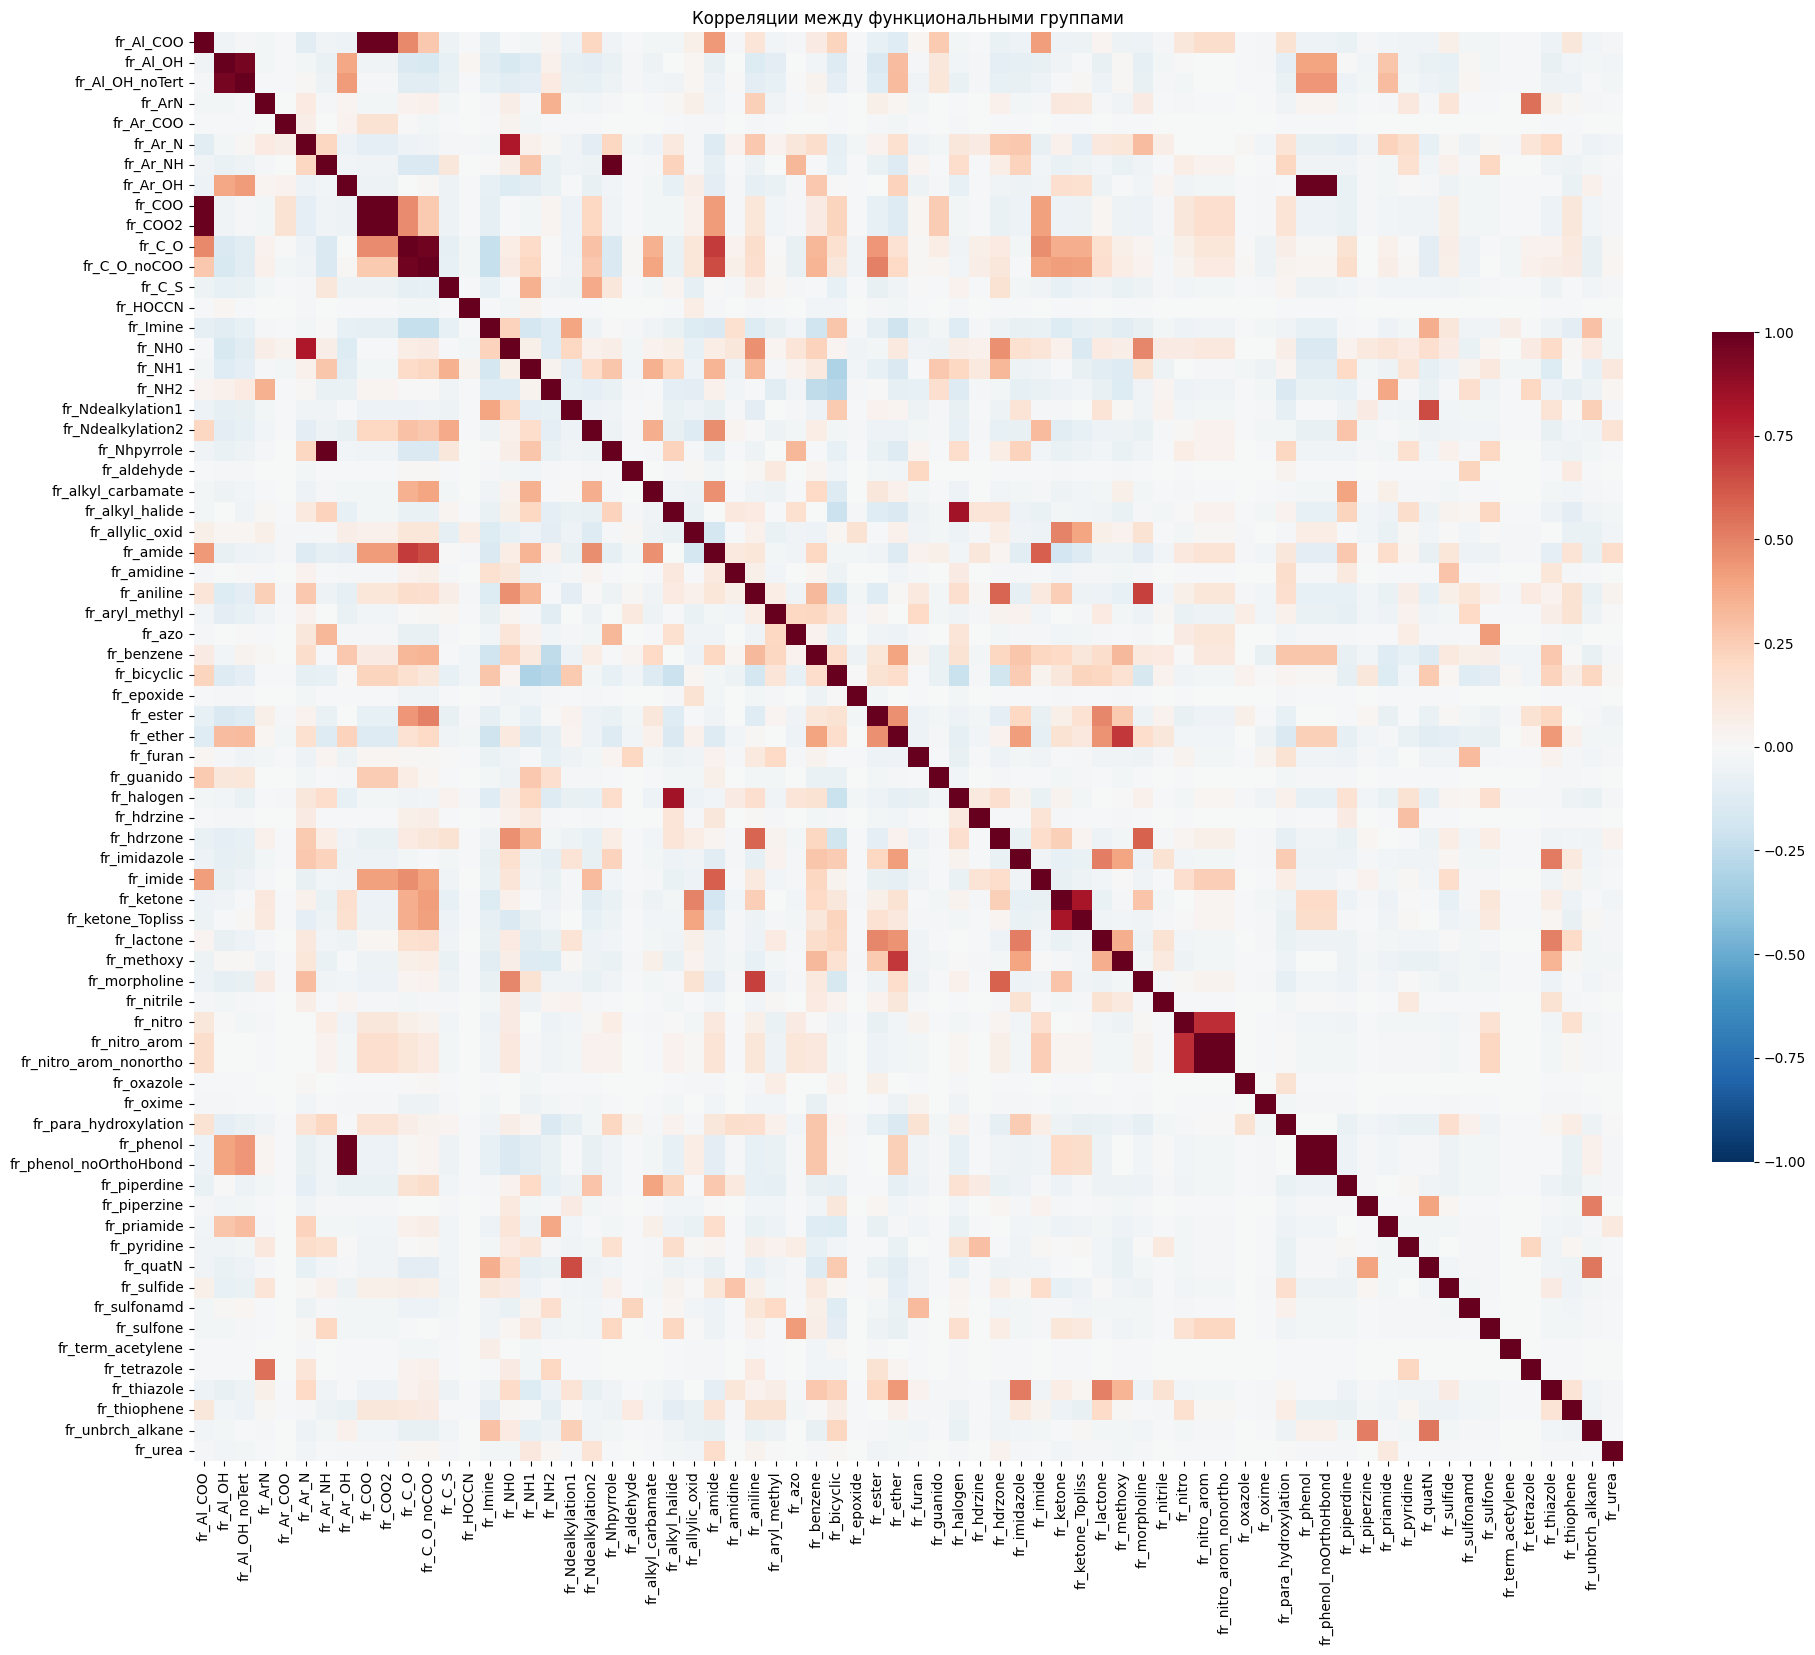

Пары с r = 1.000: 4
Пары с r >= 0.989: 2
Пары с 0.80 < r < 0.989 (оставлены): 7


In [1061]:
fr_for_corr = [c for c in group_functional_groups if c in df_train.columns]
fr_corr = df_train[fr_for_corr].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(fr_corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.5})
plt.title('Корреляции между функциональными группами')
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(fr_corr.columns)):
    for j in range(i + 1, len(fr_corr.columns)):
        r = fr_corr.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((fr_corr.columns[i], fr_corr.columns[j], r))

high_corr_pairs.sort(key=lambda x: -abs(x[2]))

identical_pairs = [(a, b, r) for a, b, r in high_corr_pairs if abs(r) == 1.0]
near_identical_pairs = [(a, b, r) for a, b, r in high_corr_pairs if 0.989 <= abs(r) < 1.0]
other_high_pairs = [(a, b, r) for a, b, r in high_corr_pairs if 0.80 < abs(r) < 0.989]

fr_identical_remove = []
seen = set()
for a, b, _ in identical_pairs:
    if a not in seen and b not in seen:
        fr_identical_remove.append(b)
        seen.add(a)
        seen.add(b)

fr_near_identical_remove = []
for a, b, _ in near_identical_pairs:
    if df_train[a].mean() >= df_train[b].mean():
        fr_near_identical_remove.append(b)
    else:
        fr_near_identical_remove.append(a)

fr_high_corr_keep = []
for a, b, _ in other_high_pairs:
    if a not in fr_high_corr_keep:
        fr_high_corr_keep.append(a)
    if b not in fr_high_corr_keep:
        fr_high_corr_keep.append(b)

if identical_pairs:
    print(f"Пары с r = 1.000: {len(identical_pairs)}")
if near_identical_pairs:
    print(f"Пары с r >= 0.989: {len(near_identical_pairs)}")
if other_high_pairs:
    print(f"Пары с 0.80 < r < 0.989 (оставлены): {len(other_high_pairs)}")


Итог: 
- 4 пары с r = 1.000 (полные дубликаты)
- 2 пары с r >= 0.989 (почти дубликаты)
- 7 пар с r=0.80-0.989.

Вывод: 
- Дубликаты (r=1.000 и r>=0.989) — удалить по одному из пары. 
- Пары с r=0.80-0.989 — оставить (химически разная информация).

### Проверка иерархических пар по корреляциям с таргетами

In [1062]:
fr_target_corr = pd.DataFrame(index=group_functional_groups, columns=['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI'], dtype=float)
for col in group_functional_groups:
    for t in ['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI']:
        fr_target_corr.loc[col, t] = df_train[col].corr(df_train[t])

In [1063]:
hierarchy_pairs = [
    (spec, gen)
    for spec, gen in [
        ('fr_ketone_Topliss', 'fr_ketone'),
        ('fr_nitro_arom_nonortho', 'fr_nitro'),
        ('fr_nitro_arom', 'fr_nitro'),
        ('fr_phenol_noOrthoHbond', 'fr_phenol'),
        ('fr_Al_OH_noTert', 'fr_Al_OH'),
        ('fr_C_O_noCOO', 'fr_C_O'),
        ('fr_Al_COO', 'fr_COO'),
        ('fr_Ar_COO', 'fr_COO'),
        ('fr_priamide', 'fr_amide'),
        ('fr_piperdine', 'fr_NH0'),
    ]
    if spec in fr_hierarchy_remove and gen not in fr_hierarchy_remove
]

confirmed = []
for spec, gen in hierarchy_pairs:
    if spec not in fr_target_corr.index or gen not in fr_target_corr.index:
        continue
    max_diff = max(
        abs(fr_target_corr.loc[spec, t]) - abs(fr_target_corr.loc[gen, t])
        for t in ['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI']
    )
    if max_diff <= 0.02:
        confirmed.append(spec)


print("Корреляция специфичного признака с таргетами меньше, чем у общего:")
print(len(confirmed),'на удаление', confirmed)

Корреляция специфичного признака с таргетами меньше, чем у общего:
7 на удаление ['fr_ketone_Topliss', 'fr_nitro_arom_nonortho', 'fr_nitro_arom', 'fr_phenol_noOrthoHbond', 'fr_Al_OH_noTert', 'fr_C_O_noCOO', 'fr_Al_COO']


Проверка удаляемых признаков и формирование финального списка

In [1064]:
fr_all = [c for c in df_train.columns if c.startswith('fr_')]

fr_target_corr = pd.DataFrame(index=fr_all, columns=['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI'], dtype=float)
for col in fr_all:
    for t in ['sqrt_IC50, mM','sqrt_CC50, mM', 'sqrt_SI']:
        fr_target_corr.loc[col, t] = df_train[col].corr(df_train[t])
  

In [1065]:
fr_check = (
    fr_very_rare + fr_hierarchy_remove +
    fr_identical_remove + fr_near_identical_remove
)
fr_check = list(dict.fromkeys(fr_check))
fr_check = [c for c in fr_check if c in df_train.columns]

max_corr_check = fr_target_corr.loc[fr_check].abs().max(axis=1)
n_weak = (max_corr_check < 0.05).sum()
n_total = len(max_corr_check)

print(f"Неконстантные удаляемые: {n_total}")
print(f"  max|r| < 0.05: {n_weak}")
print(f"  max|r| >= 0.05: {n_total - n_weak}")

fr_remove_final = fr_check
fr_keep_final = [c for c in fr_all if c not in fr_remove_final]

print(f"\nfr-признаков: было {len(fr_all)}, удалено {len(fr_remove_final)}, осталось {len(fr_keep_final)}")

Неконстантные удаляемые: 26
  max|r| < 0.05: 11
  max|r| >= 0.05: 15

fr-признаков: было 70, удалено 26, осталось 44


Итоговый анализ fragment-based дескрипторов показал, что часть признаков обладает структурной избыточностью вследствие строгих иерархических взаимосвязей между химическими фрагментами. Несмотря на то, что некоторые удаляемые дескрипторы демонстрировали умеренную корреляцию с целевыми переменными, их связь с биологическими параметрами практически полностью дублировалась более общими признаками, сохраняемыми в наборе данных.

Проведённый анализ показал, что в иерархических парах специфические дескрипторы не демонстрировали более сильной связи с таргетами по сравнению с соответствующими общими признаками. Это свидетельствует об отсутствии у удаляемых дескрипторов самостоятельной предсказательной ценности и позволяет рассматривать их как структурно избыточные.

### Корреляция оставшихся признаков с таргетами

In [1066]:
for target in sqrt_targets:
    corr = (
        df_train[fr_keep_final]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
fr_NH2              -0.181174
fr_C_S               0.174651
fr_alkyl_halide      0.154417
fr_Ndealkylation2    0.143568
fr_furan             0.127122
fr_halogen           0.110774
fr_Ndealkylation1   -0.101436
fr_nitro             0.100745
fr_Imine            -0.097712
fr_sulfide          -0.094891
dtype: float64

Корреляция с sqrt_CC50, mM:
fr_benzene        -0.213986
fr_allylic_oxid   -0.196292
fr_C_O            -0.192708
fr_NH2            -0.167075
fr_Imine           0.158244
fr_NH1            -0.137052
fr_ester          -0.132219
fr_ketone         -0.129413
fr_Ar_OH          -0.125396
fr_sulfide        -0.124788
dtype: float64

Корреляция с sqrt_SI:
fr_benzene          -0.180318
fr_NH2               0.174879
fr_Imine             0.152347
fr_allylic_oxid     -0.133096
fr_aryl_methyl      -0.110769
fr_ketone           -0.102183
fr_NH1               0.096724
fr_halogen          -0.092667
fr_Ndealkylation2   -0.089788
fr_sulfonamd         0.088053
dtype: fl

Корреляционный анализ fragment-based дескрипторов с целевыми переменными (sqrt_IC50, sqrt_CC50 и sqrt_SI) выявил преимущественно слабые и умеренные линейные зависимости между наличием отдельных химических фрагментов и биологическими свойствами исследуемых соединений.

Для sqrt_IC50 наиболее выраженные корреляции наблюдались для фрагментов fr_NH2 (r = −0.181), fr_C_S (r = 0.175) и fr_alkyl_halide (r = 0.154). Это может указывать на возможное влияние аминогрупп, серосодержащих и галогенсодержащих фрагментов на противовирусную активность молекул.

В случае sqrt_CC50 наиболее заметные отрицательные корреляции были выявлены для ароматических и карбонильных фрагментов, включая fr_benzene (r = −0.214), fr_allylic_oxid (r = −0.196) и fr_C_O (r = −0.193), что может свидетельствовать о связи данных структурных элементов с цитотоксичностью соединений.

Для индекса селективности (sqrt_SI) наиболее выраженные зависимости наблюдались для fr_benzene (r = −0.180), fr_NH2 (r = 0.175) и fr_Imine (r = 0.152). Полученные результаты позволяют предположить, что наличие первичных аминогрупп и иминных фрагментов может быть связано с повышением селективности, тогда как ароматические бензольные структуры могут оказывать противоположный эффект.

Удаление

In [1067]:
fr_removed_cols = fr_remove_final

df_train = df_train.drop(columns=fr_removed_cols, errors='ignore')

## ГРУППА 6: Специфические дескрипторы

In [1068]:
df_train[group_specific_descriptors].describe().T

,count,mean,std,min,25%,50%,75%,max
MaxAbsEStateIndex,729.0,10.903201,3.343328,2.321942,9.533754,12.256768,13.222955,15.933463
MaxEStateIndex,729.0,10.903201,3.343328,2.321942,9.533754,12.256768,13.222955,15.933463
MinAbsEStateIndex,729.0,0.180317,0.169897,0.000039,0.048038,0.121284,0.298303,1.374614
MinEStateIndex,729.0,-0.978873,1.599204,-6.992796,-1.334487,-0.419485,0.024888,1.374614
BCUT2D_MWHI,729.0,23.409324,14.790128,14.513946,16.368133,16.566747,32.092047,126.912704
BCUT2D_MWLOW,729.0,9.783173,0.515868,0.931261,9.688564,9.715847,9.967573,10.708899
BCUT2D_CHGHI,729.0,2.474558,0.155350,1.834460,2.394431,2.505671,2.590835,2.822293
BCUT2D_CHGLO,729.0,-2.350473,0.164179,-2.721859,-2.476855,-2.359188,-2.241291,-1.713605
BCUT2D_LOGPHI,729.0,2.474024,0.151187,1.932099,2.373185,2.485135,2.602532,2.791427
BCUT2D_LOGPLOW,729.0,-2.408521,0.174040,-2.785712,-2.529164,-2.396486,-2.325694,-1.647760


Группа дескрипторов EState, BCUT2D и Morgan density характеризуется умеренной вариабельностью и наличием отдельных экстремальных значений.  
BCUT2D-дескрипторы характеризуются различными диапазонами и масштабами значений. Наиболее широкий разброс наблюдается у BCUT2D_MWHI, что связано с вариабельностью молекулярных масс и размеров соединений.

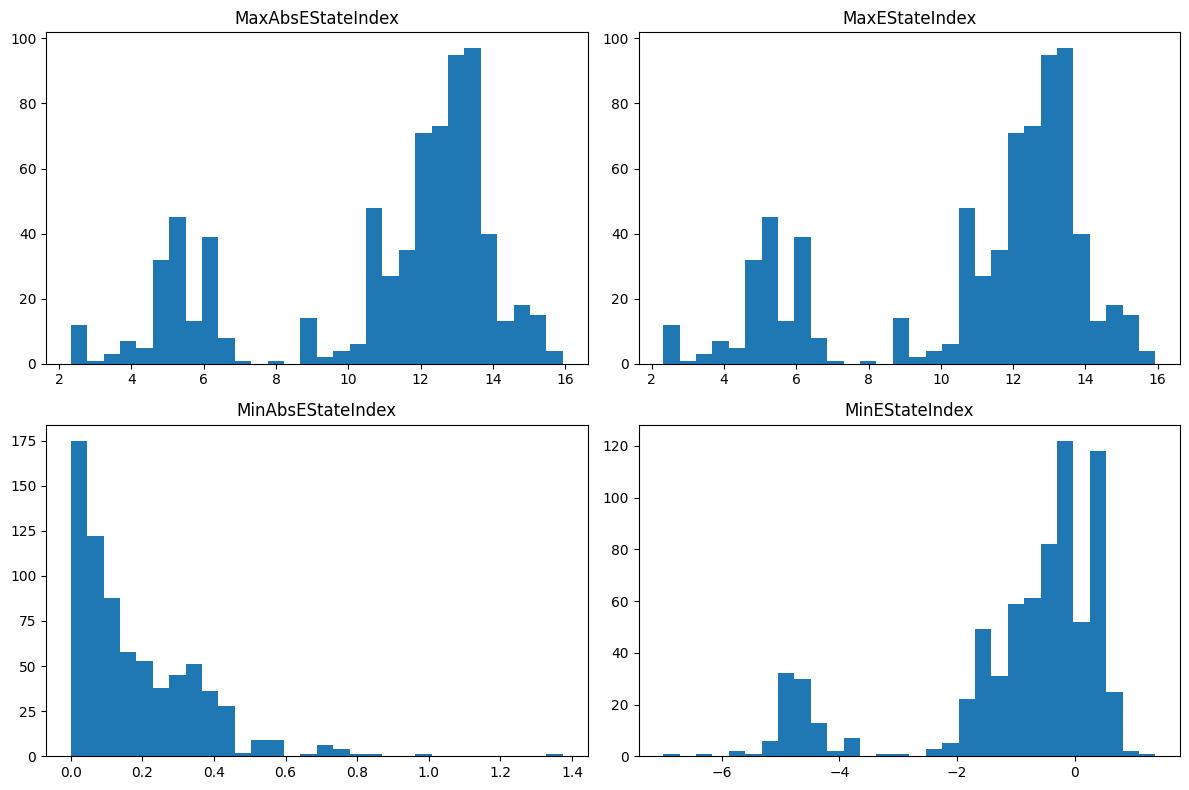

In [1069]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), group_estate_indices):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Гистограммы EState-дескрипторов демонстрируют неоднородные распределения и наличие асимметрии. Дескрипторы MaxAbsEStateIndex и MaxEStateIndex имеют практически идентичные распределения

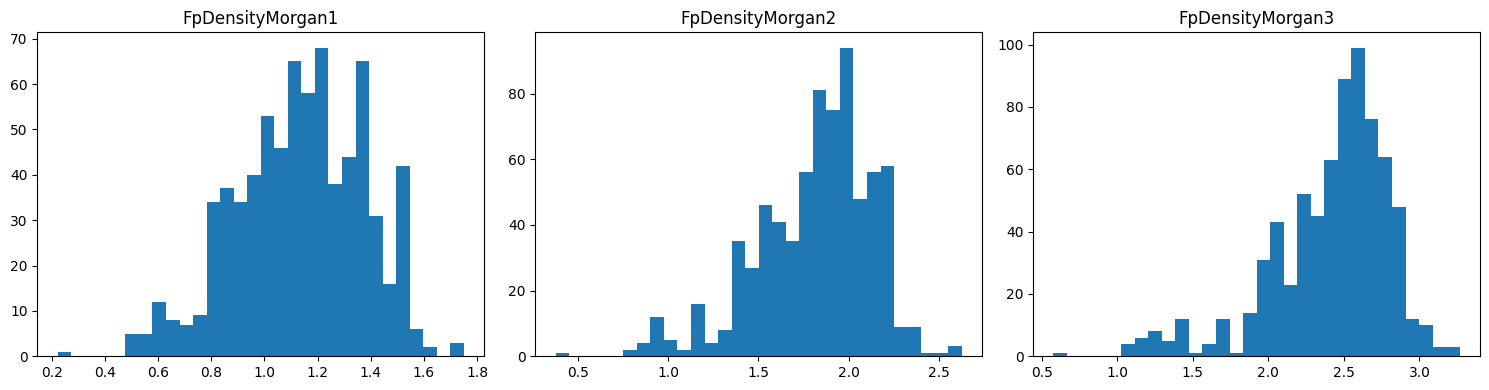

In [1070]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes.flatten(), group_morgan_density):

    ax.hist(df_train[col], bins=30)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Распределения FpDensityMorgan1, FpDensityMorgan2 и FpDensityMorgan3 являются относительно стабильными и близкими к одномодальным. С увеличением радиуса Morgan fingerprint наблюдается закономерный сдвиг распределений вправо и рост средних значений.

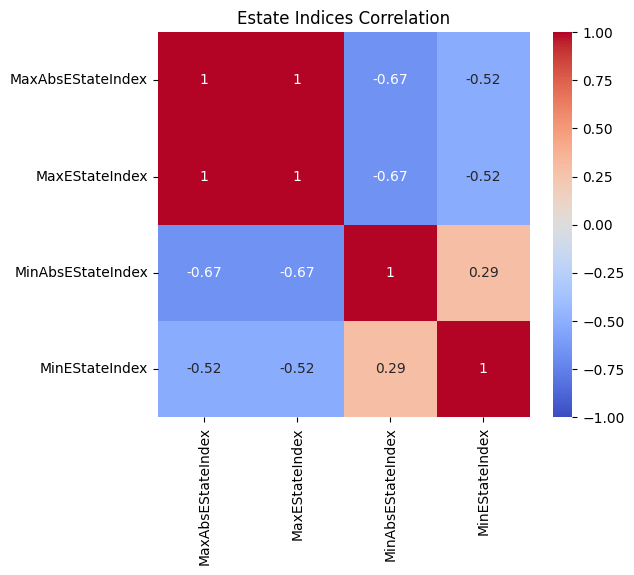

In [1071]:
corr_estate = df_train[group_estate_indices].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr_estate,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Estate Indices Correlation")
plt.show()


Корреляционный анализ показал наличие сильной мультиколлинеарности внутри группы EState-дескрипторов. Наиболее выраженная зависимость наблюдается между MaxAbsEStateIndex и MaxEStateIndex (r ≈ 1.00), что свидетельствует о полном дублировании информации.

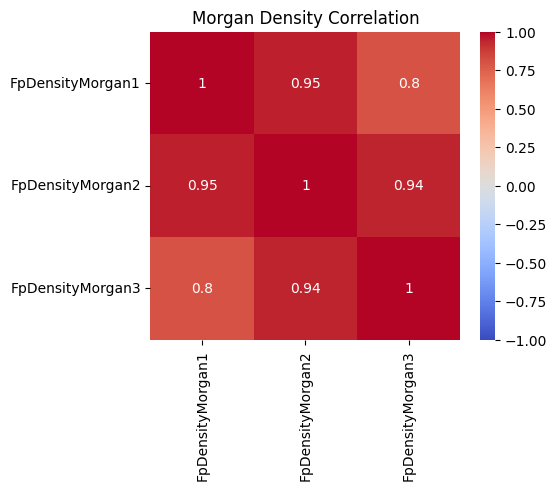

In [1072]:
corr_morgan = df_train[group_morgan_density].corr()

plt.figure(figsize=(5, 4))

sns.heatmap(
    corr_morgan,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("Morgan Density Correlation")
plt.show()


Дескрипторы Morgan density демонстрируют очень высокую взаимную корреляцию, что указывает на выраженную мультиколлинеарность и значительную избыточность информации внутри группы.

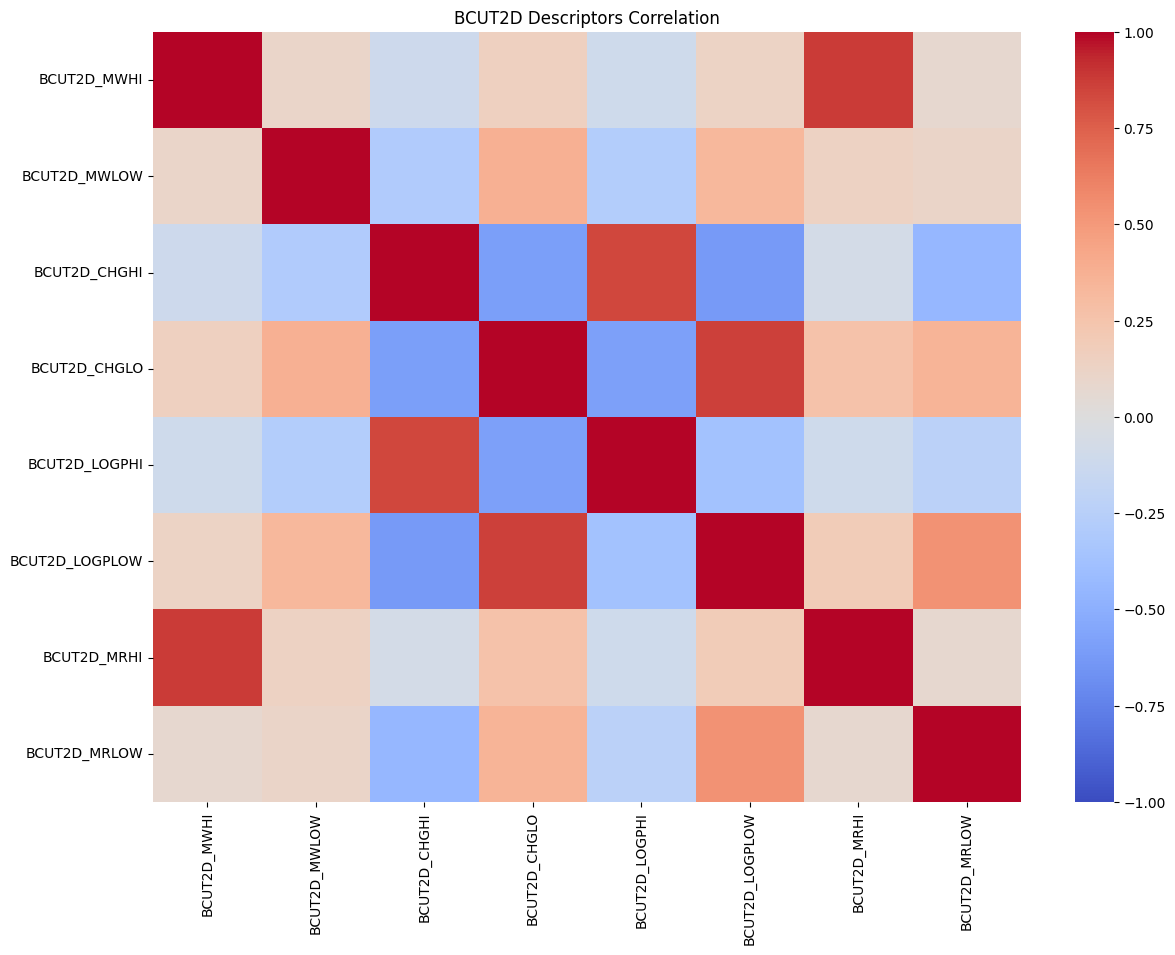

In [1073]:
corr_bcut = df_train[group_bcut].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_bcut,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title("BCUT2D Descriptors Correlation")
plt.show()

Анализ корреляционной матрицы BCUT2D-дескрипторов показал, что между разными группами преобладают слабые и умеренные корреляции, что свидетельствует о достаточно хорошей ортогональности дескрипторов. Набор BCUT2D-дескрипторов несёт достаточно разнообразную информацию о молекуле высокой мультиколлинеарности не обнаружено, удаление не требуетсяя 

In [1074]:
for target in sqrt_targets:
    corr = (
        df_train[group_specific_descriptors]
        .corrwith(df_train[target])
        .sort_values(key=abs, ascending=False)
    )
    
    print(f"\nКорреляция с {target}:")
    print(corr.head(10))


Корреляция с sqrt_IC50, mM:
MinEStateIndex      -0.182571
FpDensityMorgan1     0.157202
FpDensityMorgan2     0.155196
FpDensityMorgan3     0.151124
BCUT2D_LOGPHI       -0.143817
BCUT2D_CHGLO         0.142314
BCUT2D_MWLOW         0.132859
MaxAbsEStateIndex    0.128996
MaxEStateIndex       0.128996
MinAbsEStateIndex   -0.093559
dtype: float64

Корреляция с sqrt_CC50, mM:
FpDensityMorgan1     0.259964
FpDensityMorgan2     0.240107
BCUT2D_CHGLO         0.177197
FpDensityMorgan3     0.152034
BCUT2D_LOGPLOW       0.149580
BCUT2D_MWLOW         0.094918
MaxEStateIndex      -0.080468
MaxAbsEStateIndex   -0.080468
MinAbsEStateIndex    0.056587
BCUT2D_CHGHI         0.053380
dtype: float64

Корреляция с sqrt_SI:
BCUT2D_MWLOW        -0.182990
FpDensityMorgan1     0.143120
MaxEStateIndex      -0.126777
MaxAbsEStateIndex   -0.126777
MinEStateIndex       0.098938
FpDensityMorgan2     0.088626
BCUT2D_MWHI         -0.068641
BCUT2D_CHGLO        -0.057580
BCUT2D_MRHI         -0.057563
BCUT2D_LOGPHI      

Связь дескрипторов семейств EState, FpDensityMorgan и BCUT2D с целевыми переменными (sqrt_IC50, sqrt_CC50 и sqrt_SI) в целом остаётся слабой и умеренной. Наиболее высокие абсолютные значения коэффициентов корреляции наблюдались для FpDensityMorgan1 и FpDensityMorgan2 в отношении sqrt_CC50 (r = 0.260 и r = 0.240 соответственно), что может свидетельствовать о связи плотности молекулярных фрагментов с цитотоксичностью исследуемых соединений.

Для sqrt_IC50 наиболее выраженные корреляции были выявлены для MinEStateIndex (r = −0.183), FpDensityMorgan1 (r = 0.157), FpDensityMorgan2 (r = 0.155) и BCUT2D_LOGPHI (r = −0.144). В случае sqrt_SI наиболее заметные зависимости наблюдались для BCUT2D_MWLOW (r = −0.183), FpDensityMorgan1 (r = 0.143) и MaxEStateIndex (r = −0.127).

Среди BCUT-дескрипторов наиболее выраженные и стабильные связи с биологическими параметрами продемонстрировали BCUT2D_CHGLO, BCUT2D_LOGPHI, BCUT2D_LOGPLOW и BCUT2D_MWLOW, что может отражать влияние распределения электронной плотности, липофильности и молекулярной массы на биологическую активность и токсичность соединений.

Несмотря на то, что абсолютные значения коэффициентов корреляции в целом остаются относительно невысокими (|r| < 0.3), рассматриваемые дескрипторы потенциально могут быть полезны для нелинейных моделей машинного обучения

In [1075]:
features_to_drop = ['MaxAbsEStateIndex']

df_train = df_train.drop(columns=features_to_drop)

Полное совпадение значений (r = 1.0) также было выявлено между дескрипторами MaxAbsEStateIndex и MaxEStateIndex. Поскольку данные признаки не содержали различающейся информации, один из них (MaxAbsEStateIndex) был исключён как полностью избыточный.

## Вывод 

Корреляционный анализ показал преимущественно слабые линейные связи между дескрипторами и целевыми переменными (|r| < 0.3), что указывает на отсутствие выраженных линейных зависимостей между структурой молекул и их биологическими свойствами. Это свидетельствует о вероятном нелинейном характере данных, поэтому для дальнейшего QSAR-моделирования были выбраны нелинейные алгоритмы машинного обучения (Random Forest, CatBoost, XGBoost).

Анализ мультиколлинеарности проводился с учётом особенностей нелинейных моделей. Поскольку такие алгоритмы устойчивы к умеренной корреляции признаков, удалялись только:

- практически полные дубликаты (r > 0.98);
- структурно избыточные дескрипторы, описывающие один и тот же физико-химический смысл;
- редкие и иерархически зависимые fragment-based признаки без уникальной информации.

Такой подход позволил уменьшить избыточность признакового пространства без потери потенциально важной химической информации.

## Финальная проверка 

In [ ]:
corr_matrix = df_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

threshold = 0.98

for col in upper.columns:
    for row in upper.index:

        value = upper.loc[row, col]

        if pd.notna(value) and value > threshold:
            high_corr_pairs.append((row, col, value))

high_corr_pairs

[('Chi0v', 'Chi1v', np.float64(0.9884640031209706)),
 ('MolWt', 'LabuteASA', np.float64(0.9885497441499883)),
 ('Chi0v', 'LabuteASA', np.float64(0.98141666235905)),
 ('Chi0v', 'MolMR', np.float64(0.9894369886535012)),
 ('LabuteASA', 'MolMR', np.float64(0.9866513174895781)),
 ('NumAromaticCarbocycles', 'fr_benzene', np.float64(1.0))]

После удаления полностью дублирующихся дескрипторов в наборе данных сохранилось лишь несколько пар признаков с высокой корреляцией (r > 0.98), отражающих близкие физико-химические свойства молекул.

Высокая корреляция между Chi0v и Chi1v связана с тем, что оба дескриптора характеризуют топологическую связность молекулы. Аналогично, сильная взаимосвязь между MolWt, LabuteASA и MolMR обусловлена тем, что данные признаки описывают размер, поверхность и объёмно-поляризационные свойства молекулы.

При этом указанные дескрипторы не являются полными дубликатами и отражают разные аспекты молекулярной структуры, поэтому были сохранены для дальнейшего нелинейного QSAR-моделирования.

Полная корреляция (r = 1.0) между NumAromaticCarbocycles и fr_benzene показала полное дублирование информации, вследствие чего признак fr_benzene был удалён как избыточный.

В целом после финальной фильтрации в датасете сохранилась лишь умеренная остаточная мультиколлинеарность, допустимая для нелинейных ансамблевых моделей машинного обучения.

In [1077]:
to_drop = ['fr_benzene']

drop_test = mass_corr_cols + topology_to_drop + vsa_removed_cols + features_to_drop + fr_removed_cols + to_drop + constant_cols_train  


In [1078]:
df_train = df_train.drop(columns=to_drop)
df_test = df_test.drop(columns=drop_test)
df_test.shape

(250, 157)

In [1079]:
df_train.shape

(729, 163)

In [1080]:
train_only = sorted(set(df_train.columns) - set(df_test.columns))
test_only = sorted(set(df_test.columns) - set(df_train.columns))

print("Only in train:", train_only)
print("Only in test:", test_only)

Only in train: ['CC50, mM', 'IC50, mM', 'SI', 'sqrt_CC50, mM', 'sqrt_IC50, mM', 'sqrt_SI']
Only in test: []


In [1081]:
train_final = df_train
test_final = df_test

train_final.to_csv("../data/processed/train_final.csv", index=False)
test_final.to_csv("../data/processed/test_final.csv", index=False)
